# **第二次讀書會專案：**

**課程：** 社群媒體分析  
**教授：** 黃三益 老師  
**組別：** 第 12 組  
**組員：** 林永森 N124320002、盧鳳珠 N134320006、林㛄婷 N134020008、陳葳 N134320010、黃羽彤 N144020013、李玟娟 M145040001

---

## **專案背景與說明**

### **新青安政策簡介**
「新青年安心成家購屋優惠貸款」（簡稱新青安）由財政部於 2023 年 8 月正式推行，旨在減輕年輕首購族的購屋負擔。政策包含四大優惠：貸款額度上限提升至 1,000 萬元、貸款年限延長至 40 年、寬限期放寬至 5 年，並由政府加碼補貼利息至 1.775% 之地板利率。該政策雖顯著推升首購族進場意願，卻也因後續引發的房市過熱與人頭戶爭議，促使政府於 2024 年陸續增設「一生限貸一次」與「自住切結書」等管控措施。

### **專案動機**
自「新青安」貸款政策推行以來，房地產市場熱度與爭議並行。而房地產市場與金融市場高度連動，相關議題不僅集中於特定社群，也經常跨社群擴散。例如 PTT 房板主要聚焦於購屋、政策與房價，而股板則常從投資、資金流動與市場預期的角度切入。即使討論相同議題，不同社群之間仍可能呈現出差異化的語言使用方式與表達風格（如語氣、用詞習慣與關注重點）。在大量社群文本持續產生的情境下，若能自動辨識文本所屬的討論脈絡（如房市導向或投資導向），將有助於後續的資訊整理、主題分析與輿情觀察。因此，建立一個可有效區分不同社群語境的文本分類模型，具有實務上的基礎價值。

### **專案目的**
本專案以 PTT 房板與股板為例，建立一套可重現的中文文本分類流程，目標如下：
1. 建立基礎社群文本分類模型：透過文本前處理、特徵轉換（TF-IDF）與傳統機器學習模型，實現對不同社群語境（房市 vs 投資）的自動分類，作為後續應用（如內容分流、主題分析）的前置模組。
2. 分析不同社群語言特徵差異：探討房板與股板在討論相似議題時，是否存在可被模型捕捉的詞彙、語意與語言風格差異（如語氣與用詞習慣），進一步理解分類結果的可解釋性。
3. 評估輕量模型在中文短文本上的效果：驗證在中文論壇短文本情境下，「規則化前處理 + TF-IDF + 線性模型」是否能在成本與效能之間取得平衡，作為實務應用中的高效率解法。
4. 比較不同模型對語義重疊問題的處理能力：在房市與投資議題高度交疊的情境下，比較不同模型（如 LR、RF、SVC、CNB、LSA）在分類表現上的差異，分析其對語義模糊邊界的處理能力。

---

## **報告大綱**

### **資料概況**
* **資料來源**：透過 TarFlow 蒐集 PTT 房屋板、股票板文章。
* **關鍵字**：新青安
* **時間範圍**：2023-08-01 ~ 2026-03-20
* **原始資料量**：共 464 篇文章
* **本次專案資料篩選**：
  * 所有推文
  * 文章分類為「Re:」、「[心得]」、「[閒聊]」的內文
  * 其餘文章分類取「心得：」、「心得/評論：」文字後到文章結尾的所有內容


### **分析流程**

 * **1. 資料工程**：原始 PTT 資料拆分、清理、合併為可訓練文本。
 * **2. 語言前處理**：自訂字典/停用詞/同義詞 + CKIP 斷詞/POS。
 * **3. 探索分析**：詞頻、bigram/trigram 文字雲觀察語言差異。
 * **4. 特徵建構**：TF-IDF（以 unigram/bigram 為主，trigram 為擴展測試）。
 * **5. 模型訓練比較**：LR、RF、SVC、CNB、LSA+SVC。
 * **6. 指標與可解釋性輸出**：分類報告 + 關鍵詞權重/重要度。
 * **7. 結論收斂**：以實測結果選擇最實用方案，並記錄失敗嘗試。

---

## 1. 資料清理

### 1.1 載入套件與參數

- 功能：載入文本處理、中文斷詞、向量化、機器學習、視覺化所需套件（如 CKIPTagger、pandas、sklearn、wordcloud）。
- 目的：建立完整 NLP 分類管線的依賴環境。
- 模型族群以傳統機器學習（TF-IDF + 線性/樹模型/貝氏）為主，不是深度學習語言模型。

In [1]:
from ckiptagger import construct_dictionary, WS, POS, NER
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import json
import re
import unicodedata
import math
import time
from nltk import ngrams
from wordcloud import WordCloud
from collections import Counter
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB

### 1.2 環境與模型路徑設定

- 功能：設定 matplotlib 中文字型與負號顯示，建立 CKIP 模型路徑與 ws/pos/ner 物件。
- 目的：確保中文圖表可讀，並讓後續中文斷詞與詞性標註可直接執行。
- 特徵工程高度仰賴中文斷詞品質；此 cell 是特徵品質基礎。

In [2]:
# 設定圖的中文字體 (無法顯示的話可以試試‘Microsoft JhengHei’字體)
# 也可參考：https://pyecontech.com/2020/03/27/python_matplotlib_chinese/
# 1. 設定 matplotlib 的全域字型 (以 Windows 微軟正黑體為例)
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] #使圖中中文能正常顯示
# 2. 解決負號無法顯示的問題 (如果有畫座標軸的話)
plt.rcParams['axes.unicode_minus'] = False #使負號能夠顯示

# CKIP
# 若要使用 GPU：
#    步驟1. 安裝 TensorFlow (CkipTagger的後端) 的 CUDA (Nvidia GPU) 支援
#       (command line)
#       python -m pip install tensorflow[and-cuda]
#    步驟2. 設定 CUDA_VISIBLE_DEVICES 環境變數
#       (python script)
#       os.environ["CUDA_VISIBLE_DEVICES"] = "0"
#    步驟3. 設定 disable_cuda=False
#       (python script)
#       ws = WS("./data", disable_cuda=False)
#       pos = POS("./data", disable_cuda=False)
#       ner = NER("./data", disable_cuda=False)

ws = WS("./ckipdata/data")
pos = POS("./ckipdata/data")
ner = NER("./ckipdata/data")

D:\git\python_homework\.venv\Lib\site-packages\ckiptagger\model_ws.py:106: UserWarning: `tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by that in Tensorflow 2.0.
  cell = tf.compat.v1.nn.rnn_cell.LSTMCell(hidden_d, name=name)
D:\git\python_homework\.venv\Lib\site-packages\ckiptagger\model_pos.py:56: UserWarning: `tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by that in Tensorflow 2.0.
  cell = tf.compat.v1.nn.rnn_cell.LSTMCell(hidden_d, name=name)
D:\git\python_homework\.venv\Lib\site-packages\ckiptagger\model_ner.py:57: UserWarning: `tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by that in Tensorflow 2.0.
  cell = tf.compat.v1.nn.rnn_cell.LSTMCell(hidden_d, 

### 1.3 原始資料清理與結構重組

- 功能：讀取原始 CSV，解析 artComment JSON、拆分主文與推文、合併同作者推文、清理正文（去網址/簽名檔/分類抽取等），輸出多個中繼資料檔。
- 目的：把結構混雜的論壇資料轉成可訓練語料。
- 先做資料工程再建模，減少噪音對分類邊界的干擾。

主要步驟與產出：
| 步驟 | 說明 | 產出 |
| -- | -- | -- |
| 分離PO文與推文 | 取出`artComment`欄位並將json物件正規化組成新csv檔案<br>推文檔以`system_id`串接<br>PO文檔案移除`artComment`欄位 | `home_stoke_comments.csv` <br> `home_stoke_posts_main.csv` |
| 合併推文 | 將同一篇PO文的同一人推文合併 | `home_stoke_merged_comments.csv`|
| 清理文章 | 從`artTitle`中取出PO的的分類 <br> 根據不同分類只取出心得部分*1 <br> 清除網址、簽名檔、多餘空行 | `home_stoke_cleaned_posts.csv` |
| 合併PO文心得與推文 | 將PO文心得部分與推文合併，並清除無內容資料 | `home_stoke_combined_posts_comments.csv` |
| 清理合併後內文 | 移除網址 <br> 將全形英數字轉半形 <br> 將英文字母統一轉大寫 <br> 處理換行與空白 <br> 輸出為最終使用檔案 | `home_stoke_basic_cleaned.csv` |

- *1 本次資料只使用PO文者心得部分，故保留分類是「Re:」, 「\[心得\]」, 「\[閒聊\]」的內文全文。此外只保留固定格式中，有「心得：」或「心得/評論：」後所有文字。此做法會無法取得\[情報\]或\[請益\]等其他類型文章中的心得。

- `home_stoke_comments.csv`欄位：

| 欄位名 | 說明 |
| -- | -- |
| `cmtId` | 留言id，流水號 |
| `system_id` | 原文`system_id`，用來串回原文章 |
| `artCatagory` | 原文的`artCatagory`，為方便分析保留 |
| `cmtStatus` | 推/噓/→ |
| `cmtPoster` | 推文ID |
| `cmtContent` | 推文內容 |
| `cmtDate` | 推文時間 |

- `home_stoke_combined_posts_comments.csv`

| 欄位名 | 說明 |
| -- | -- |
| `system_id` | 原PO文`system_id` |
| `artCatagory` | 原PO文的`artCatagory`，為方便分析保留 |
| `artTitle` | 原PO文的標題 |
| `cntDate` | PO時間(`artDate`)或推文時間(`cmtDate`) |
| `subTitle` | 原PO文分類 |
| `content` | PO文內容(`artContent`)或推文內容(`cmtContent`) |
| `cntPoster` | PO文者ID(`artPoster`)或推文ID(`cmtPoster`) |
| `cntType` | 標記是PO文(固定放值`POST`)或推文(固定放值`COMMENT`) |

- 本次作業使用`home_stoke_basic_cleaned.csv`檔案。

In [ ]:
# 1. 讀取原始 CSV 檔案
df_raw = pd.read_csv('data/ptt_home_sale_stoke.csv')

# 2. 定義解析 JSON 的函式
def parse_art_comment(comment_str):
    try:
        # 處理 PTT 資料中常見的雙引號重複問題，並轉為 Python 物件
        clean_str = comment_str.replace('""', '"')
        return json.loads(clean_str)
    except Exception as e:
        # 若解析失敗（例如空值），回傳空清單
        return []

# 3. 解析留言欄位
df_raw['artComment'] = df_raw['artComment'].apply(parse_art_comment)

# 4. 使用 explode 將「文章對應多個留言物件」展開成「一列一個留言物件」
# 此時每一列都會保留原本文章的 system_id
df_exploded = df_raw[['system_id', 'artCatagory', 'artComment']].explode('artComment')

# 5. 移除沒有留言的文章列（若原本就沒留言，artComment 會是 NaN 或空）
df_exploded = df_exploded.dropna(subset=['artComment'])

# 6. 將留言物件（Dict）扁平化為獨立欄位
# 使用 json_normalize 將字典屬性轉為欄位
comments_data = pd.json_normalize(df_exploded['artComment'])

# 7. 重新對齊索引並合併 system_id
# 因為 explode 後索引會重複，重設索引以利合併
df_exploded = df_exploded.reset_index(drop=True)
comments_data = comments_data.reset_index(drop=True)

df_final_comments = pd.concat([df_exploded[['system_id', 'artCatagory']], comments_data], axis=1)

# 移除 cmtContent 欄位最開頭的冒號
# ^: 代表只匹配字串開頭的冒號
df_final_comments['cmtContent'] = df_final_comments['cmtContent'].str.replace('^:', '', regex=True)

# 8. 新增 cmtId 作為流水號（從 1 開始）
# 這能確保即使 cmtDate 相同，我們也能知道原始的先後順序
df_final_comments.insert(0, 'cmtId', range(1, len(df_final_comments) + 1))

# 9. 儲存為新的留言 CSV 檔案
#df_final_comments.to_csv('data/home_stoke_comments.csv', index=False, encoding='utf-8-sig')

print(f"處理完成！共產生 {len(df_final_comments)} 筆留言資料。")

df_posts_main = df_raw.drop(columns=['artComment'])
# 接著輸出成新檔案
#df_posts_main.to_csv('data/home_stoke_posts_main.csv', index=False, encoding='utf-8-sig')
print("主貼文資料已儲存，artComment 欄位已移除。")

### 合併留言
# 將 cmtContent 的空值補成空字串，並確保所有內容都是 str
df_final_comments['cmtContent'] = (
    df_final_comments['cmtContent']
    .fillna('')
    .astype(str)
    .str.normalize('NFKC')
    .str.upper()
)

# 直接按文章 (system_id) 和發言人 (cmtPoster) 進行分組合併
# 將同一個人在同一篇文下的所有留言內容接在一起
df_merged_total = df_final_comments.groupby(['system_id', 'artCatagory', 'cmtPoster']).agg({
    'cmtContent': lambda x: ''.join(x),
    'cmtDate': 'min',    # 保留該使用者的「第一次發言」時間
    'cmtStatus': 'first' # 保留該使用者的「第一個動作」 (通常是推/噓/→)
}).reset_index()

# 2. 轉換時間格式（選擇性，若要按時間分析則必須做）
df_merged_total['cmtDate'] = pd.to_datetime(df_merged_total['cmtDate'])
print(f"合併完成！目前留言總數：{len(df_merged_total)}")

#df_merged_total.to_csv('data/home_stoke_merged_comments.csv', index=False, encoding='utf-8-sig')
print("合併留言資料已儲存。")

################# 清理PO文 #################

# 1. 讀取原始資料
#df = pd.read_csv('data/home_stoke_posts_main.csv')
df = df_posts_main.copy()

# 2. 定義擷取文章分類的函數
def extract_subtitle(title):
    if not isinstance(title, str):
        return ''
    title = title.strip()
    if title.startswith('Re:'):
        return 'Re:'
    match = re.match(r'^(\[.*?\])', title)
    if match:
        return match.group(1)
    return ''

df['subTitle'] = df['artTitle'].apply(extract_subtitle)

# 3. 定義清理內文的函數
def clean_content(row):
    content = row['artContent']
    subtitle = row['subTitle']
    
    if not isinstance(content, str):
        return content
        
    # 若分類不是 'Re:', '[心得]', '[閒聊]'，才擷取心得或評論之後的內容
    if subtitle not in ['Re:', '[心得]', '[閒聊]']:
        match = re.search(r'(心得(?:/評論)?[:：])(.*)', content, flags=re.DOTALL)
        if match:
            content = match.group(2).strip()
        else:
            content = ''

    # 如果內容已經被清空，就不用執行後續的正規表達式，直接回傳即可
    if not content:
        return ''
                
    # (2) 移除網址與圖片連結 (匹配 http:// 或 https:// 開頭，直到遇到空白字元的字串)
    content = re.sub(r'https?://\S+', '', content)         

    # (3) 移除簽名檔 (支援單行與多行)
    # (?:\s+[^\n]+){0,2} 表示允許 Sent from 後面再跟著 0 到 2 行的文字
    #content = re.sub(r'(?:[-—_]+\s*\n)?\s*Sent from(?:\s+[^\n]+){0,2}', '', content, flags=re.IGNORECASE)
    # 暴力解法：直接刪除 Sent from 到文章結尾的所有內容
    content = re.sub(r'(?:[-—_]+\s*\n)?\s*Sent from.*', '', content, flags=re.IGNORECASE | re.DOTALL)

    # (4) 移除兩個以上的連續換行
    # 將 \n{2,} (也就是連續兩個以上的換行符號) 替換為單一換行符號 \n
    # 註：若希望能保留「空一行」來做段落分隔，可以將 r'\n{3,}' 替換為 '\n\n'
    content = re.sub(r'\n{2,}', '\n', content)
    
    return content.strip()

# 套用清理函數至內文欄位
df['artContent'] = df.apply(clean_content, axis=1)

# 4. 輸出至新的 CSV 檔案
#df.to_csv('data/home_stoke_cleaned_posts.csv', index=False, encoding='utf-8-sig')

################# 合併PO文心得與推文 #################

#posts_file = 'data/home_stoke_cleaned_posts.csv'  # 剛剛清理過的第一份文章資料
#comments_file = 'data/home_stoke_merged_comments.csv'       # 第二份留言資料

# 1. 讀取兩份資料
#df_posts = pd.read_csv(posts_file)
df_posts = df.copy()
#df_comments = pd.read_csv(comments_file)
df_comments = df_merged_total.copy()

# 2. 從第一份文章資料中提取 system_id 對應的 artTitle 與 subTitle
# 使用 drop_duplicates() 確保每個 system_id 只有一筆對應記錄
mapping_df = df_posts[['system_id', 'artTitle', 'subTitle']].drop_duplicates()

# 將 artTitle 與 subTitle 合併 (Left Join) 到留言資料中
df_comments = df_comments.merge(mapping_df, on='system_id', how='left')

# 3. 將兩份資料整理成相同的目標欄位格式
# 目標欄位：system_id, artCatagory, artTitle, cntDate, subTitle, content, cntPoster

# (A) 整理文章資料：選取需要的欄位並重新命名
df_posts_unified = df_posts[[
    'system_id', 'artCatagory', 'artTitle', 'artDate', 'subTitle', 'artContent', 'artPoster'
]].rename(columns={
    'artDate': 'cntDate',
    'artContent': 'content',
    'artPoster': 'cntPoster'
}).assign(cntType='POST')

# (B) 整理留言資料：選取需要的欄位並重新命名
df_comments_unified = df_comments[[
    'system_id', 'artCatagory', 'artTitle', 'cmtDate', 'subTitle', 'cmtContent', 'cmtPoster'
]].rename(columns={
    'cmtDate': 'cntDate',
    'cmtContent': 'content',
    'cmtPoster': 'cntPoster'
}).assign(cntType='COMMENT')

# 4. 合併 (Concatenate) 這兩份已經對齊欄位的資料表
df_combined = pd.concat([df_posts_unified, df_comments_unified], ignore_index=True)

# (選擇性) 依照 system_id 與日期進行排序，這樣同一篇文章與其底下的留言就會排在一起
df_combined = df_combined.sort_values(by=['system_id', 'cntDate']).reset_index(drop=True)

# 4. 移除 artContent 為空值或空字串的資料列
# 先移除原本就是 NaN 的資料，再排除清理後變為空字串的資料
df_combined = df_combined.dropna(subset=['content'])
df_combined = df_combined[df_combined['content'] != '']

# 5. 輸出成新的 CSV 檔案
#output_filename = 'data/home_stoke_combined_posts_comments.csv'
#df_combined.to_csv(output_filename, index=False, encoding='utf-8-sig')

#print(f"資料合併完成！已輸出至 {output_filename}")

################# 清理合併後內文 #################
# 1. 讀取合併後的檔案
#df = pd.read_csv('data/home_stoke_combined_posts_comments.csv')
df_final = df_combined.copy()

# 2. 移除 content 欄位是空值的資料
df_final = df.dropna(subset=['content']).copy()

# 3. 定義統一的資料清理函數
def clean_all_text(text):
    if not isinstance(text, str):
        return text
        
    # (1) 移除網址 (優先執行，避免網址字元被後續的全半形或大寫轉換影響)
    text = re.sub(r'https?://\S+', '', text)
    
    # (2) 全半形轉換 (NFKC 模式：將全形英數字轉為半形)
    text = unicodedata.normalize('NFKC', text)
    
    # (3) 將英文字母統一轉為大寫
    text = text.upper()
    
    # (4) 處理換行與空白
    # 將所有換行符號 (\n, \r)、Tab (\t) 與全形空白替換為單一空白
    text = re.sub(r'[\r\n\t　]+', ' ', text)
    # 將連續的空白壓縮為單一空白 (\s+ 包含各種空白字元)
    text = re.sub(r'\s+', ' ', text)
    
    # (6) 去除字串頭尾的空白
    return text.strip()

# 4. 套用統一的清理函數
df_final['content'] = df_final['content'].apply(clean_all_text)

# 5. 再次過濾：確保清理後變為空字串的資料也被剔除
df_final = df_final[df_final['content'] != '']
df_final = df_final.dropna(subset=['content']).copy()

# 6. 輸出成最終清理後的 CSV 檔案
output_filename = 'data/home_stoke_basic_cleaned.csv'
df_final.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f"基礎清理完成！已移除網址、統一格式、轉換同義詞並壓縮空白，已輸出至 {output_filename}")


處理完成！共產生 38067 筆留言資料。
主貼文資料已儲存，artComment 欄位已移除。
合併完成！目前留言總數：17689
合併留言資料已儲存。


NameError: name 'output_filename' is not defined

## 2. 語言前處理

### 2.1 自訂詞典/停用詞/同義詞讀取工具

- 功能：定義讀取文字清單檔案、同義詞映射與替換函式。
- 目的：把 PTT 黑話、錯別字、簡稱做可控標準化。
- 以「規則式語言正規化」增強 TF-IDF 的可解釋性。

本次使用的字典：
- `user_dict.txt`：配合PTT專有名詞與黑話，需建立自定義字典
- `stopwords.txt`：斷詞使用的停用詞，以無意義語氣詞為主
- `whitelist.txt`：因斷詞時會排除長度為1的單子，為保留可能有特殊意義的字，建立白名單
- `synonyms.txt`：自定義同義詞字典。為保留論壇中用語特殊性，只轉換常見錯別字、語氣詞、或不具語意特殊性的用字統一(例如將「股版」轉為「股板」、「台積」轉為「台積電」，保留「台GG」不轉換)
- `analysis_stopwords.txt`：模型訓練階段發現，具有顯著影響的雜訊，例如「這麼」、「那麼」。為減少對語意判斷的影響，不在斷詞階段排除的詞彙。

In [3]:
###################################
# 若有修改檔案內容則重新執行這個cell
# 有修改synonyms.txt需重新執行載入資料與CKIPTagger斷詞詞性標註
# 有修改user_dict.txt需重新執行CKIPTagger斷詞詞性標註
# 修改其他檔案則需重新執行組裝
###################################

def read_txt_lines(file_path):
    """
    讀取純文字檔，去除每行頭尾空白、換行與 BOM，
    過濾空行後，回傳乾淨的文字列表。
    """
    line_list = []
    with open(file_path, 'r', encoding='utf-8-sig') as f:
        for line in f:
            text = line.strip().replace('\ufeff', '')
            if text:
                line_list.append(text)
    return line_list

def read_user_dict(file_path, default_weight=100):
    """
    讀取 user_dict.txt
    支援兩種格式：
    1. 詞
    2. 詞 權重

    回傳 CKIPTagger 可用的 {詞: 權重} dict
    """
    word_weight_dict = {}

    with open(file_path, 'r', encoding='utf-8-sig') as f:
        for line in f:
            text = line.strip().replace('\ufeff', '')
            if not text:
                continue

            parts = text.split()

            if len(parts) == 1:
                word = parts[0]
                weight = default_weight
            else:
                word = parts[0]
                try:
                    weight = int(parts[1])
                except ValueError:
                    print(f"警告：{file_path} 中這行權重格式錯誤，改用預設值 {default_weight}：{text}")
                    weight = default_weight

            word_weight_dict[word] = weight

    return word_weight_dict
# === 2. 載入並進行各自的格式處理 ===

# user_dict
user_weight_dict = read_user_dict("./dict/user_dict.txt", default_weight=100)
user_dict = construct_dictionary(user_weight_dict)

# stopwords
stop_words = set(read_txt_lines("./dict/stopwords.txt"))
# 分析時過濾詞
analysis_stop_words = set(read_txt_lines('./dict/analysis_stopwords.txt'))

# whitelist
whitelist = set(read_txt_lines("./dict/whitelist.txt"))

# synonyms
synonym_map = {}
for line in read_txt_lines("./dict/synonyms.txt"):
    if ':' in line:
        target, variants = line.split(':', 1)
        for v in variants.split(','):
            synonym_map[v.strip().upper()] = target.strip().upper()
# 為了避免「新青安」被先換成「青安」，取代順序要由長到短
sorted_variants = sorted(synonym_map.keys(), key=len, reverse=True)
# 定義同義詞取代函式
def replace_synonyms(text):
    for variant in sorted_variants:
        if variant in text:
            text = text.replace(variant, synonym_map[variant])
    return text

### 2.2 載入清理後語料並套同義詞

- 功能：讀 `home_stoke_basic_cleaned.csv`、去空值、建立 `cleaned_content`，並檢視分類數量。
- 目的：形成可斷詞、可訓練的乾淨語料。
- 資料明顯不平衡（home_sale 13634 vs Stock 4429），後續模型必須處理。

In [4]:
# === 2. 讀取並清理 CSV 資料 ===
df = pd.read_csv('./data/home_stoke_basic_cleaned.csv')

# 剔除空值
df = df.dropna(subset=['content']).copy()

# 套用清理：由於網址與空白已在輸出 csv 前處理完畢，這裡直接套用同義詞轉換
df['cleaned_content'] = df['content'].apply(replace_synonyms)

# artCatagory每種各有幾筆
print(df['artCatagory'].value_counts())


artCatagory
home_sale    13634
Stock         4429
Name: count, dtype: int64


### 2.3 建立斷詞測試資料

- 功能：準備 text_to_segment（實際上使用全資料 copy）。
- 目的：提供 CKIP 批次輸入。

In [5]:
df_test = df.copy()
#df_test = df_test[~((df_test['artCatagory'] == 'Stock') & (df_test['subTitle'] == '[情報]') & (df_test['cntType']=='POST'))]
#df_test = df_test[(df_test['artCatagory'] == 'home_sale') & (df_test['subTitle'] != '[新聞]')].head(50)
text_to_segment = df_test['cleaned_content'].tolist()


### 2.4 CKIP 斷詞 + 詞性標註 + 過濾

- 功能：執行 ws 與 pos，用條件過濾不必要 token（如數字型態、特定詞性、停用詞等），產生 `segmented_content`。
- 目的：保留高語意密度詞彙，降低雜訊。
- 斷詞在前、向量化在後，屬「先語言前處理再數值化」流程。
- 偏重可解釋特徵工程

執行流程：
1. 停用字過濾(Stopwords Removal)：移除對語意分析無貢獻，或過短不具有意義的詞彙。
2. 處理數量+單位的組合，將常見的數字單位組合組成一個token，供後續分析。
3. 詞性標記(POS)：辨識每個詞的詞性，保留名詞 (N*) 和動詞 (V*)，因為它們通常承載了最多的核心資訊或情感價值。保留白名單中的特定副詞(D)，以保留可能的否定或程度副詞等。
4. 特徵表示與向量化(Vectorization)：算 `TF-IDF` 或 `詞頻`

In [6]:
#修改版1, 考慮詞性
print("開始執行 CKIPTagger 斷詞與詞性標註...")
start = time.time()
# 執行斷詞 (記得確保 ws 模型已經載入)
ws_results = ws(text_to_segment, coerce_dictionary=user_dict)
# 詞性標註
pos_results = pos(ws_results) 

end = time.time()
print('完成, time costing: {}'.format(end - start))

開始執行 CKIPTagger 斷詞與詞性標註...
完成, time costing: 246.77251362800598


In [7]:
def is_number_like(word):
    patterns = [
        r"^\d+$",                              # 10
        r"^[一二三四五六七八九十百千萬億]+$",    # 十、二十、三百
        r"^[一二三四五六七八九十百千萬億]+幾$",  # 十幾、二十幾
        r"^[一二三四五六七八九十百千萬億]+多$",  # 十多、二十多
    ]
    return any(re.match(p, word) for p in patterns)

# === 進行停用詞、詞性與單字過濾，並組裝結果 ===
start = time.time()
final_segmented_texts = []

# 同時遍歷斷詞與詞性結果
for sentence_words, sentence_tags in zip(ws_results, pos_results):
    cleaned_words = []
    i = 0

    while i < len(sentence_words):
        word = sentence_words[i]
        tag = sentence_tags[i]

        # 數量詞 + 單位 合併
        if (
            i < len(sentence_words) - 1
            and is_number_like(word)
            and sentence_words[i + 1] in {"年", "月", "天", "分鐘", "小時", "日", "元", "萬", "億", "%", "次", "倍"}
        ):
            # 將數值與單位合併為一個詞
            word = word + sentence_words[i + 1]
            i += 2
        else:
            i += 1

        # 停用詞過濾
        if word in stop_words:
            continue

        # === 核心修改：利用詞性取代單純的單字過濾 ===
        # 解析 CKIP 的詞性標記
        is_noun = tag.startswith('N')  # 名詞類 (Na 普通名詞, Nb 專有名詞等)
        is_verb = tag.startswith('V')  # 動詞類 (VA, VC 等)
        is_adv = tag.startswith('D')   # 副詞類 (包含：不、沒、很、太)
        is_particle = tag.startswith('T') or tag.startswith('DE') # 語助詞或結構助詞 (的、了、吧)

        # 決定是否保留此詞的旗標
        keep_word = False
        
        # 條件 1：名詞與動詞通常是關鍵字主力，直接保留
        if is_noun or is_verb:
            keep_word = True
            
        # 條件 2：如果是副詞，且存在於 whitelist (例如裡面有 '不', '沒', '不要')
        # 這樣就能強行保住單個字的否定詞
        elif is_adv and word in whitelist:
            keep_word = True
            
        # 條件 3：其他未涵蓋的詞性，若長度 > 1 且不是無意義的助詞，則保留
        # 這可以確保合併出來的「數量+單位」(例如: 十年) 或其他複合詞能順利通關
        elif len(word) > 1 and not is_particle:
            keep_word = True

        if keep_word:
            cleaned_words.append(word)

    final_text = " ".join(cleaned_words)
    final_segmented_texts.append(final_text)

# 將結果存回測試用的 DataFrame
df_test['segmented_content'] = final_segmented_texts

# === 5. 檢視測試結果 ===
#for index, row in df_test.iterrows():
#    print(f"[{row['artCatagory']}]")
#    print("原文：", row['content'])
#    print("清整：", row['cleaned_content'])
#    print("斷詞：", row['segmented_content'])
#    print("=" * 50)
end = time.time()
print('完成, time costing: {}'.format(end - start))

完成, time costing: 11.531596660614014


#### 檢視斷詞結果
顯示前 10 筆 segmented_content，以檢視人工驗證斷詞/過濾策略是否合理。

In [9]:
df_test['segmented_content'].head(10)

0    進入 傳統 Q3 淡季 而且 中南部 有 風災 雨災 影響 有點 倒楣 專家 建議 可能 忍...
1    台南 房仲 吃土 過 寒冬 頂尖 戰將 團隊 去年 做 一億 業績 今年 上半年 2000萬...
2                                              關 店面 不會
3                                       沒有 不景氣 只有 不 爭氣
4                                  房板 瞧不起 整 天 抱怨 環境 魯蛇
5    腦多 抱怨 環境 說 現在 房子 沒有 流動性 從來 不會 檢討 自己 為什麼 賣 盤子價 ...
6                           4月 關稅 大刀 讓 很多 人 資產 縮水 變 保守
7                              這 個 版 20% 後 當然 保守 觀望 極致
8                  政府 出來 拯救 房地產 市場 房地產 倒 台灣 完蛋 台幣 變 廢紙
9                     怎麼 可能 救 房地產 救 產業 沒有 產業 怎麼 扶持 房地產
Name: segmented_content, dtype: str

#### 前處理與斷詞

- CKIP 斷詞+詞性流程耗時約 256 秒，代表以 CPU 執行大型語料時成本不低。
- 斷詞樣本顯示已能保留主題詞（如「關稅」「房地產」「產業」），部分數量單位和黑話也有成功保留（如「4月」、「20%」、「房板」、「腦多」）


### 2.5 詞頻統計

- 功能：展平 token、計算詞頻、建立詞頻表。
- 目的：了解語料高頻詞，支援停用詞調整。
- 以探索式分析回饋特徵清理。用於輸出檢查。

In [ ]:
# 1. 將所有列的 list 攤平成一個巨大的 list
all_tokens = [token for text in df_test['segmented_content'] for token in text.split()]
filtered_tokens = [t for t in all_tokens if len(t) > 1]
# 2. 使用 Counter 計算每個詞出現的次數
word_counts = Counter(filtered_tokens)

# 3. 轉換成 DataFrame 方便閱讀與後續處理
df_counts = pd.DataFrame(word_counts.items(), columns=['word', 'count']).sort_values(by='count', ascending=False)

#pd.set_option('display.max_rows', None)
#print(df_counts.head(500))
#pd.reset_option('display.max_rows')
#for word, count in word_counts.most_common():
#    print(f"{word}: {count}")
#df_counts.to_csv("./data/word_frequency.csv", index=False, encoding="utf-8-sig")

## 3. 資料分析

### 3.1 N-gram 萃取與雙詞組文字雲

- 功能：定義過濾後 n-gram 產生函式，分板塊統計雙詞組並視覺化。
- 目的：觀察兩社群語言搭配差異。
- bigram 是核心判別資訊之一，對線性模型很重要。

[房板 (home_sale) 雙詞組文字雲] 前 10 大: [('怎麼 可能', 68), ('信用 管制', 64), ('地板 利率', 42), ('貸款 成數', 39), ('房地 合一', 38), ('新青安 不是', 34), ('根本 不是', 33), ('銀行 自己', 32), ('不是 這樣', 32), ('因為 新青安', 31)]


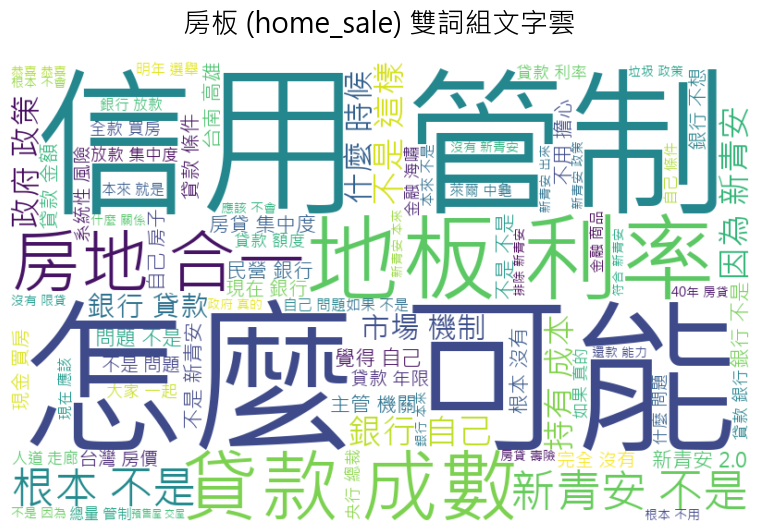

[股板 (Stock) 雙詞組文字雲] 前 10 大: [('經濟 火車頭', 43), ('繼續 炒房', 23), ('時空背景 不同', 20), ('台灣 房價', 18), ('政府 炒房', 15), ('不是 這樣', 14), ('政治 獻金', 13), ('垃圾 政府', 12), ('建商 爸爸', 12), ('放款 集中度', 12)]


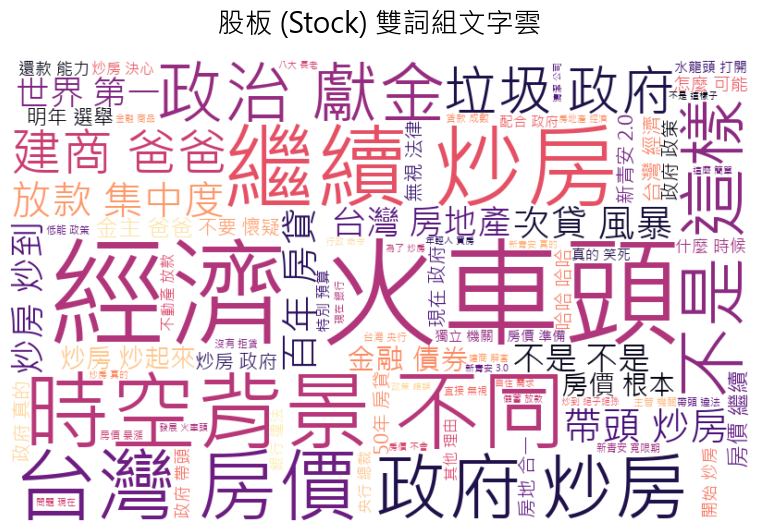

In [10]:
# 3. 定義產生過濾後 N-gram 的函式
def get_filtered_ngrams(text, n=2):
    if not isinstance(text, str):
        return []
        
    words = text.split()
    valid_ngrams = []
    
    # 產生 N-gram
    for i in range(len(words) - n + 1):
        ngram_words = words[i:i+n]
        
        # 檢查這個 N-gram 裡面有沒有任何詞是停用詞，或長度小於2
        # 如果有，我們就不要這個 N-gram
        is_valid = True
        for w in ngram_words:
            if w in analysis_stop_words or len(w) < 2:
            #if w in analysis_stop_words or (len(w) < 2 and w not in whitelist):
                is_valid = False
                break
                
        if is_valid:
            valid_ngrams.append(' '.join(ngram_words))

        #寬鬆過濾
        #has_meaningful_word = any(w not in analysis_stop_words and len(w) >= 2 for w in ngram_words)
        #if has_meaningful_word:
        #valid_ngrams.append(' '.join(ngram_words))
        
    return valid_ngrams

# 4. 分別收集房板與股板的 Bigram
#unigram_home = []
#unigram_stoke = []
bigrams_home = []
bigrams_stock = []
trigrams_home = []
trigrams_stock = []

for index, row in df_test.iterrows():
    board = row['artCatagory']
    text = row['segmented_content']
    
    ngrams = get_filtered_ngrams(text, n=2)
 #   unigram = get_filtered_ngrams(text, n=1)
    trigrams = get_filtered_ngrams(text, n=3)

    if board == 'home_sale':
        bigrams_home.extend(ngrams)
#        unigram_home.extend(unigram)
        trigrams_home.extend(trigrams)
    elif board == 'Stock':
        bigrams_stock.extend(ngrams)
#        unigram_stoke.extend(unigram)
        trigrams_stock.extend(trigrams)


# 5. 定義畫文字雲的共用函式
def plot_wordcloud(ngram_list, title, colormap):
    counts = Counter(ngram_list)
    print(f"[{title}] 前 10 大:", counts.most_common(10))
    
    font_path = 'C:/Windows/Fonts/msjh.ttc'  # 微軟正黑體 (Mac 請改 /System/Library/Fonts/PingFang.ttc)
    
    wc = WordCloud(
        font_path=font_path, width=800, height=500,
        background_color='white', max_words=80, colormap=colormap
    )
    wc.generate_from_frequencies(counts)
    
    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title, fontsize=20, pad=20)
    plt.axis('off')
    plt.show()

# 6. 畫圖！
# 房板用藍綠色系，股板用紅橘色系，方便區分
#plot_wordcloud(unigram_home, "房板 (home_sale) 文字雲", "viridis")
#plot_wordcloud(unigram_stoke, "股板 (Stock) 文字雲", "magma")

plot_wordcloud(bigrams_home, "房板 (home_sale) 雙詞組文字雲", "viridis")
plot_wordcloud(bigrams_stock, "股板 (Stock) 雙詞組文字雲", "magma")


#### Bigram 結果

- 房板雙詞常見「信用管制、地板利率、貸款成數、房地合一」；股板常見「經濟火車頭、時空背景不同、政府炒房」，顯示兩板在主題關注上存在明顯差異。  
- 兩板皆出現「不是這樣」等跨社群流行語，反映特定時期的共通語言風格。此類詞彙雖不具明顯主題區分力，但其在不同類別中的實際分布差異，仍可能被模型利用，顯示語意重疊與語言風格訊號同時存在。

#### 3.1.1 Trigram 文字雲嘗試

- 功能：繪製兩板 tri-gram 文字雲。
- 目的：觀察三詞共現語意是否提供額外可分訊號。
- 偏探索視覺化，不直接代表泛化效能提升。

[房板 (home_sale) 三詞組文字雲] 前 10 大: [('不是 不是 這樣', 16), ('新青安 垃圾 政策', 8), ('不可能 絕對 不可能', 8), ('不會 全款 買房', 7), ('我們 繼續 看下去', 7), ('回歸 市場 機制', 7), ('不動產 放款 集中度', 7), ('實際 收入 PR', 7), ('收入 PR 不到', 7), ('PR 不到 50', 7)]


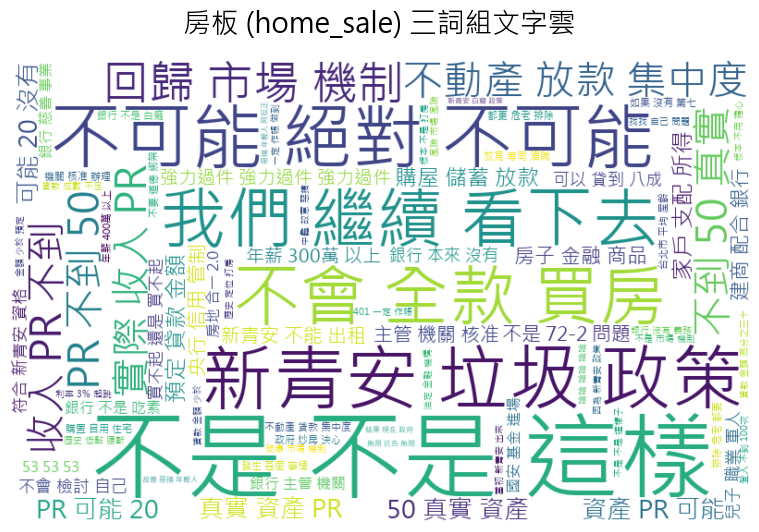

[股板 (Stock) 三詞組文字雲] 前 10 大: [('不是 不是 這樣', 7), ('房地產 經濟 火車頭', 5), ('不動產 放款 集中度', 5), ('政府 帶頭 炒房', 4), ('炒房 炒到 絕子絕孫', 4), ('購屋 儲蓄 放款', 4), ('台灣 經濟 發展', 4), ('經濟 發展 火車頭', 4), ('吸收 更多 存款', 3), ('經濟 火車頭 不能', 3)]


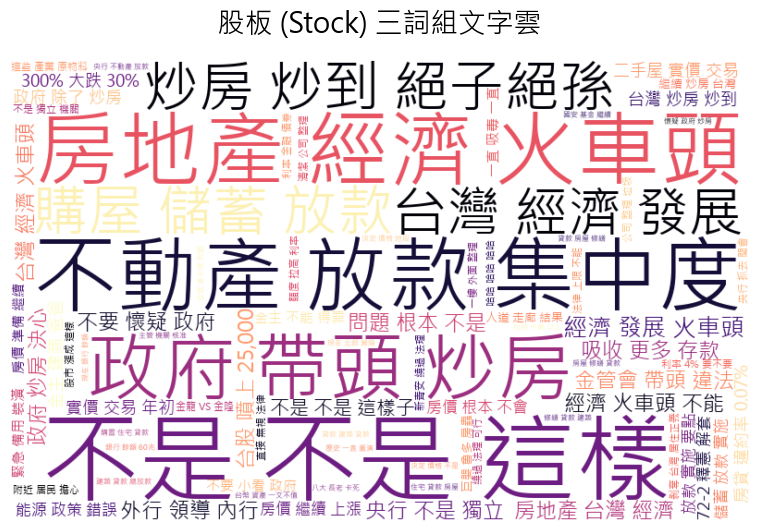

In [11]:
plot_wordcloud(trigrams_home, "房板 (home_sale) 三詞組文字雲", "viridis")
plot_wordcloud(trigrams_stock, "股板 (Stock) 三詞組文字雲", "magma")

- **觀察結果與限制**

  Trigram 結果顯示，部分三詞組（如「房地產 經濟 火車頭」、「政府 帶頭 炒房」）具有較明確的語意指向，能反映特定社群的討論框架，具備潛在的分類價值。然而，同時也觀察到如「不是 不是 這樣」等跨板共用的語氣或迷因用語，顯示語言風格在不同社群間具有一定程度的共享。

  整體而言，trigram 雖能提供較強的語意資訊，但其出現頻率較低、特徵較為稀疏，覆蓋率有限，因此較適合作為輔助觀察工具，而非主要特徵來源。此結果亦與後續模型實驗一致：trigram 對部分模型（如 ComplementNB）可能有幫助，但對需要穩定特徵分布的模型（如 Logistic Regression）則未必帶來效能提升。

### 3.2 建立 TF-IDF 前的二次清理

- 功能：去除 segmented_content 空值、定義分析階段過濾函式（analysis_stop_words + 長度規則），建立 final_content。
- 目的：將「斷詞停用詞」與「建模停用詞」分層管理。
- 動態停用詞策略，降低資料洩漏與過濾過度風險。

In [8]:
raw_tfidf = df_test.copy()

raw_tfidf = raw_tfidf.dropna(subset=['segmented_content'])

# 2. 定義二次清理函數 (動態濾除分析停用詞)
def filter_for_analysis(text):
    words = text.split()
    # 濾掉停用詞，且只保留長度 >= 2 的詞 (除非在白名單，這裡先簡化處理)
    filtered = [w for w in words if w not in analysis_stop_words and len(w) >= 2]
    return " ".join(filtered)

raw_tfidf['final_content'] = raw_tfidf['segmented_content'].apply(filter_for_analysis)


#### 補充動態停用
- 功能：加入額外雜訊詞（如「不是」、「這樣」）。
- 目的：針對誤差來源做針對性降噪。
- 使用程式快速測試避免一直讀檔重做

在實作過程中觀察到，停用詞的效果具有明顯的任務依賴性。在傳統主題分析任務中，語氣詞與結構詞通常可視為低資訊量特徵而予以移除；然而在本研究的社群文本分類情境中，部分語氣詞與用詞習慣會反映不同社群的語言風格，對分類結果具有實際貢獻。停用詞應視為特徵選擇的一部分，需依據任務目標與模型表現進行調整。

經實驗觀察，在本研究的社群文本分類任務中，過度移除停用詞反而會降低模型表現。部分語氣詞與用詞習慣雖非主題詞，但在不同社群中呈現分布差異，對分類具有輔助訊號。因此，適度保留此類詞彙有助於提升模型效果。

In [9]:
# 手動加入過濾詞彙
extra_stops = [] #['不是', '這樣']
final_stop_words = list(analysis_stop_words) + extra_stops


### 3.3 TF-IDF 特徵建模與可視化

- 功能：以 unigram~trigram 建立 TF-IDF（max_features=3000），輸出特徵圖。
- 目的：先做特徵空間探索，確認詞權重分布。
- 不做參數調整，先根據稀疏高維向量、詞頻逆文頻加權，檢查是否有需動態過濾的詞。

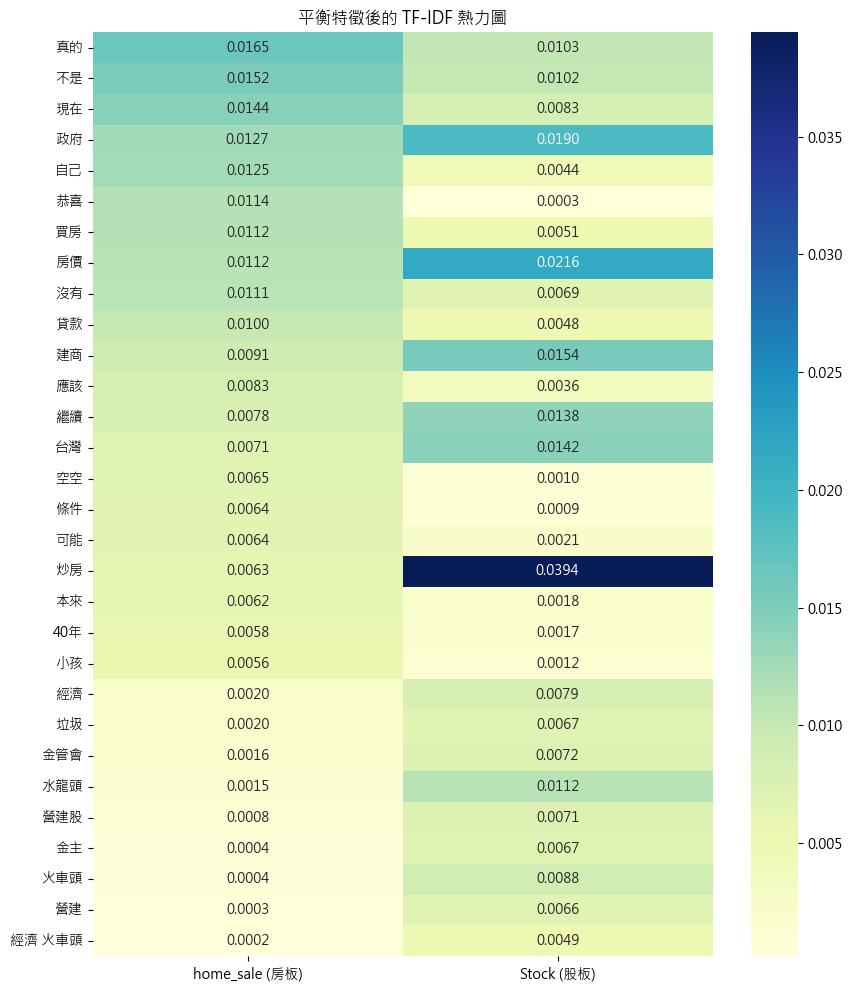

In [14]:
# 2. 計算 TF-IDF
hm_vectorizer = TfidfVectorizer(
            ngram_range=(1, 3), 
            max_features=3000,
            stop_words=final_stop_words, # 強制在向量化階段濾除
)
hm_df = raw_tfidf.copy()
hm_tfidf_matrix = hm_vectorizer.fit_transform(hm_df['final_content'])
hm_feature_names = hm_vectorizer.get_feature_names_out()

# 3. 為了讓熱力圖均衡，分別找出兩邊最強的詞
is_home = (hm_df['artCatagory'] == 'home_sale').values
is_stock = (hm_df['artCatagory'] == 'Stock').values

# 計算各板平均分數
mean_home = np.asarray(hm_tfidf_matrix[is_home].mean(axis=0)).flatten()
mean_stock = np.asarray(hm_tfidf_matrix[is_stock].mean(axis=0)).flatten()

# 計算「差異度」 (房板分數 - 股板分數)
diff1 = mean_home - mean_stock

# 選取房板最強的前 15 個特徵 (diff 正值最大)
top_home_idx = np.argsort(diff1)[-15:]
# 選取股板最強的前 15 個特徵 (diff 負值最大)
top_stock_idx = np.argsort(diff1)[:15]

# 合併索引
selected_indices = np.concatenate([top_home_idx, top_stock_idx])
hm_selected_features = [hm_feature_names[i] for i in selected_indices]

# 4. 準備繪製平衡後的熱力圖
plot_df = pd.DataFrame({
    'home_sale (房板)': mean_home[selected_indices],
    'Stock (股板)': mean_stock[selected_indices]
}, index=hm_selected_features)

# 排序以便觀察
plot_df = plot_df.sort_values(by='home_sale (房板)', ascending=False)

plt.figure(figsize=(10, 12))
sns.heatmap(plot_df, annot=True, cmap="YlGnBu", fmt=".4f")
plt.title("平衡特徵後的 TF-IDF 熱力圖")
plt.show()

* 此圖呈現移除過濾詞後，兩個看板（房板、股板）各自 TF-IDF 權重最高的前 15 個特徵詞，用以觀察不同社群的語言使用差異。
* 房板的高權重詞除了主題相關詞（如「買房」、「自己」、「貸款」）外，也包含多個語氣詞（如「真的」、「不是」、「現在」），**顯示討論偏向個人經驗與主觀表達**。
* 股板的高權重詞則集中於政策、產業與投資相關（如「炒房」、「建商」、「營建股」、「火車頭」），語言風格較偏分析與市場導向。
* 部分詞彙（如「房價」、「政府」）同時出現在兩個看板，但其權重分布不同，顯示同一詞在不同社群中的重要性存在差異。
* 整體而言，此結果說明 TF-IDF 不僅反映主題差異，也捕捉到社群之間的語言風格差異，對分類模型具有實際區分能力。


### 3.4 建立共用評估函式

`evaluate_model`：
- 功能：封裝分類報表、混淆矩陣、ROC/PR 等圖表流程。
- 目的：統一不同模型的比較標準。
- 以 precision/recall/f1 為核心，符合不平衡資料評估需求。

`get_high_confidence_errors`：
- 功能：利用 predict_proba 取得模型對每一個樣本屬於各個類別的信心值，並填回原始的結果表，方便比對
- 目的：進行模型的誤差分析（Error Analysis）
- 用來偵測極端異常
```
# --- 使用範例 ---
errors = get_high_confidence_errors(
    clf, 
    X_test_tfidf, 
    y_test, 
    texts=X_test,  # <--- 關鍵：把原始文字丟進去
    target_actual='home_sale', 
    target_pred_label='Stock', 
    threshold=0.8
)

# 只印出內容的前 50 個字
pd.set_option('display.max_colwidth', 100) # 設定 Pandas 顯示文字的長度
print(errors[['content', 'actual', 'Stock']].head(10))
```

`get_model_importance`：
- 功能：查看對模型判定最重要的n個詞彙
- 目的：檢查雜訊詞

In [15]:
# ==========================================
# 定義共用模型評估函式
# ==========================================
def evaluate_model(clf, X_test, y_test, y_pred, model_name):
    # 1. 印出文字報表
    print(f"=== {model_name} 準確度報告 ===")
    print(classification_report(y_test, y_pred))
    
    # 2. 建立 1x3 的畫布，將三張圖橫向並排
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 圖 A: 混淆矩陣
    cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
    disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
    disp_cm.plot(cmap='Blues', ax=axes[0], values_format='d')
    axes[0].set_title(f'混淆矩陣 ({model_name})', pad=15)
    
    # 圖 B: PR 曲線
    PrecisionRecallDisplay.from_estimator(clf, X_test, y_test, ax=axes[1], name=model_name)
    axes[1].set_title('PR 曲線 (專注少數類別)', pad=15)
    axes[1].grid(alpha=0.3)
    
    # 圖 C: ROC 曲線
    RocCurveDisplay.from_estimator(clf, X_test, y_test, ax=axes[2], name=model_name)
    axes[2].plot([0, 1], [0, 1], linestyle='--', color='gray', label='隨機猜測')
    axes[2].set_title('ROC 曲線與 AUC', pad=15)
    axes[2].grid(alpha=0.3)
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 模型的誤差分析（Error Analysis）
# ==========================================
def get_high_confidence_errors(model, X_test, y_true, texts, target_actual, target_pred_label, threshold=0.8):
    """
    找出模型判斷錯誤且信心值超過門檻的樣本。
    
    參數：
    - model: 訓練好的分類模型
    - X_test: 測試集特徵 (例如 TF-IDF 矩陣)
    - y_true: 真正的標籤 (Series 或 List)
    - texts: 原始的文章內容 (例如 X_test 原始字串列表或 Series)
    - target_actual: 想要觀察的真實類別 (例如 'home_sale')
    - target_pred_label: 模型誤判成的類別 (例如 'Stock')
    - threshold: 信心值門檻 (預設 0.8)
    """
    
    # 1. 取得預測機率
    probs = model.predict_proba(X_test)
    
    # 2. 建立暫存 DataFrame
    # model.classes_ 會回傳類別名稱，例如 ['Stock', 'home_sale']
    prob_df = pd.DataFrame(probs, columns=model.classes_)
    
    # 3. 整合文字、真實標籤與預測結果
    # 把 texts 也放進來，並確保索引對齊
    analysis_df = pd.DataFrame({
        'content': texts.values if hasattr(texts, 'values') else texts,
        'actual': y_true.values if hasattr(y_true, 'values') else y_true,
        'pred': model.predict(X_test)
    })
    
    # 合併機率欄位
    analysis_df = pd.concat([analysis_df, prob_df], axis=1)
    
    # 4. 篩選極端錯誤：實際是 A，但模型覺得是 B 的機率 > threshold
    error_mask = (analysis_df['actual'] == target_actual) & (analysis_df[target_pred_label] > threshold)
    
    extreme_errors = analysis_df[error_mask].sort_values(by=target_pred_label, ascending=False)
    
    return extreme_errors

# 查看模型到底學到了什麼，列出「對模型判定最重要」的各 n 個詞彙

def get_model_importance(vectorizer, clf, n=10):
    feature_names = vectorizer.get_feature_names_out()
    
    # 1. 判斷模型類型並取得分數
    if hasattr(clf, 'coef_'):
        # 針對 LogisticRegression, LinearSVC
        # model.coef_[0] 存放著特徵的權重分數
        coefs = clf.coef_[0]
        
    elif hasattr(clf, 'feature_log_prob_'):
        # 針對 ComplementNB, MultinomialNB
        # feature_log_prob_ 的形狀是 (類別數量, 特徵數量)
        prob_0 = clf.feature_log_prob_[0] # 類別 0 的特徵對數機率
        prob_1 = clf.feature_log_prob_[1] # 類別 1 的特徵對數機率
        
        # 將 類別1 的機率 減去 類別0 的機率
        # 這樣就能做出類似 Logistic Regression 的效果：
        # 正數越大代表越傾向類別1，負數越小(絕對值大)代表越傾向類別0
        coefs = prob_1 - prob_0
        
    else:
        raise ValueError("不支援的模型類型：找不到 coef_ 或 feature_log_prob_ 屬性")

    # 2. 延用你原本的排序邏輯
    # 權重最小的 (負分) 代表第一類，權重最大的 (正分) 代表第二類
    sorted_idx = np.argsort(coefs)
    
    # 取出 Top N 的關鍵詞 (以下假設你原本的寫法類似這樣)
    top_0_idx = sorted_idx[:n]          # 最小的前 n 個
    top_1_idx = sorted_idx[-n:][::-1]   # 最大的前 n 個 (並反轉順序讓最大的排前面)
    
    top_0 = [(feature_names[i], coefs[i]) for i in top_0_idx]
    top_1 = [(feature_names[i], coefs[i]) for i in top_1_idx]
    
    # 假設你的分類標籤是透過 clf.classes_ 取得
    labels = clf.classes_
    
    return labels, top_0, top_1

### 3.5 拆分資料集

In [10]:
# 準備共用資料 (假設 raw_tfidf 和 final_stop_words 已準備好)
df = raw_tfidf.copy()
X = df['final_content'] 
y = df['artCatagory']

# 2. 切分訓練集與測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


### 3.6 Logistic Regression 主模型

- 功能：以 bigram TF-IDF（max_features=5000, min_df=5, 自訂 token_pattern + 停用詞）訓練 LR，輸出分類報告與正負權重關鍵詞。
- 目的：建立可解釋且穩定的基線模型。
- 線性可解釋（係數可讀）、對高維稀疏文本有效。

=== LR 模型 準確度報告 ===
              precision    recall  f1-score   support

       Stock       0.47      0.70      0.56       886
   home_sale       0.88      0.74      0.81      2727

    accuracy                           0.73      3613
   macro avg       0.68      0.72      0.68      3613
weighted avg       0.78      0.73      0.75      3613



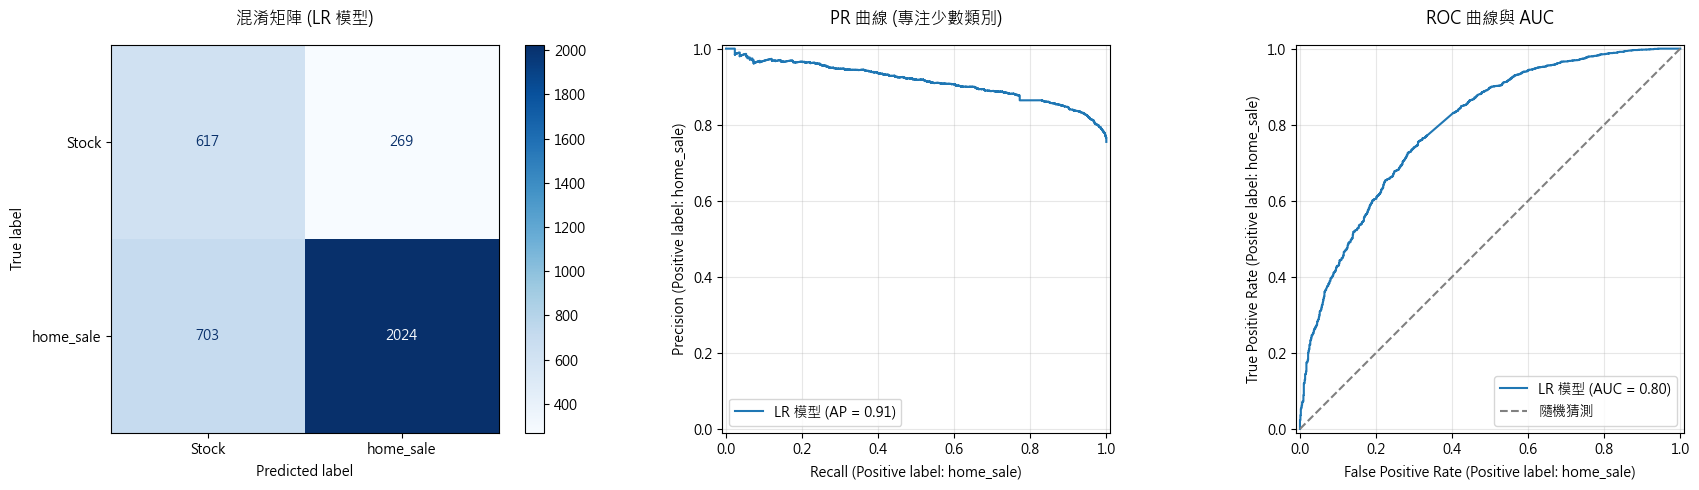


<<< 傾向判定為 Stock 的最強關鍵詞 >>>
營建              (權重: -3.1988)
炒房              (權重: -3.0771)
營建股             (權重: -2.9247)
金主              (權重: -2.9007)
火車頭             (權重: -2.8703)
水龍頭             (權重: -2.8085)
天條              (權重: -2.7719)
不同              (權重: -2.3834)
金管會             (權重: -2.3178)
法律              (權重: -2.2813)

<<< 傾向判定為 home_sale 的最強關鍵詞 >>>
恭喜              (權重: 3.2108)
阿龍              (權重: 2.7965)
空空              (權重: 2.7866)
條件              (權重: 2.5820)
自己              (權重: 2.5753)
本來              (權重: 2.4662)
信貸              (權重: 2.4633)
多多              (權重: 2.4463)
不錯              (權重: 2.3913)
但是              (權重: 2.2249)


In [17]:
# 1. 向量化
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), 
    max_features=5000, 
    min_df=5,
    stop_words=final_stop_words,  # 強制在向量化階段濾除
    #token_pattern=r"(?u)\b[^\d\W]+\b" # 只抓「非數字」的純文字詞彙
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# 2. 訓練模型
# 正規化強度 C=1.0
clf = LogisticRegression(class_weight='balanced', C=1.0, max_iter=1000)
clf.fit(X_train_tfidf, y_train)

# 評估模型準確度
y_pred = clf.predict(X_test_tfidf)

# 3. 呼叫共用函式產生報表與圖表
evaluate_model(clf, X_test_tfidf, y_test, y_pred, "LR 模型")


labels, top_0, top_1 = get_model_importance(vectorizer, clf)

print(f"\n<<< 傾向判定為 {labels[0]} 的最強關鍵詞 >>>")
for word, score in top_0:
    print(f"{word:15} (權重: {score:.4f})")

print(f"\n<<< 傾向判定為 {labels[1]} 的最強關鍵詞 >>>")
for word, score in top_1:
    print(f"{word:15} (權重: {score:.4f})")


##### 結果

- accuracy 0.73；Stock 的 P/R/F1 = 0.47/0.70/0.56。
- 是一個「平衡度不錯」的基準模型：整體準確率不差，少數類別 Stock 的 recall 也有拉上來（0.70）。
- 但 Stock precision 只有 0.47，表示「判成 Stock 的樣本中，誤判比例偏高」。
- LR 權重詞具明顯社群差異
  - 偏 Stock：營建、炒房、金主、火車頭、金管會
  - 偏 home_sale：恭喜、阿龍、空空、條件、自己
- 模型確實學到討論板語言風格，而非隨機噪音。

**適合用在「寧可多抓、不要漏抓」的情境；但若要求「判為 Stock 就要很準」，則可能未達水準。**

In [20]:
lr_errors = get_high_confidence_errors(
    clf, 
    X_test_tfidf, 
    y_test,
    texts=X_test,
    target_actual='home_sale', 
    target_pred_label='Stock', 
    threshold=0.8
)
#pd.set_option('display.max_colwidth', 100) # 設定 Pandas 顯示文字的長度
#print(lr_errors[['content', 'actual', 'Stock']].head(10))
print('實際為房板，被判斷成股板')
for idx, row in lr_errors.head(10).iterrows():
    print(f"--- 信心值: {row['Stock']:.4f} ---")
    print(f"內容摘要: {row['content'][:250]}...") # 只看前 200 字
    print("-" * 50)

實際為房板，被判斷成股板
--- 信心值: 0.9194 ---
內容摘要: 房仲 大勝 經濟 火車頭 啟動 ~~...
--------------------------------------------------
--- 信心值: 0.9176 ---
內容摘要: 反觀 台灣 經濟 火車頭 嘻嘻...
--------------------------------------------------
--- 信心值: 0.9076 ---
內容摘要: 現在 政府 官員 國家 著想 台灣 以後 怎樣...
--------------------------------------------------
--- 信心值: 0.9073 ---
內容摘要: 丸子...
--------------------------------------------------
--- 信心值: 0.8991 ---
內容摘要: 一起 泡泡...
--------------------------------------------------
--- 信心值: 0.8976 ---
內容摘要: 審判 政府 違法...
--------------------------------------------------
--- 信心值: 0.8944 ---
內容摘要: 房貸 100年 只要 20萬 炒起來...
--------------------------------------------------
--- 信心值: 0.8814 ---
內容摘要: 垃圾 執政黨 大開 炒房...
--------------------------------------------------
--- 信心值: 0.8773 ---
內容摘要: 全力 炒房...
--------------------------------------------------
--- 信心值: 0.8763 ---
內容摘要: 炒房 訊號...
--------------------------------------------------


### 3.7 Random Forest 比較模型

- 功能：同樣 TF-IDF 特徵下訓練 RF，輸出成效與特徵重要度。
- 目的：比較非線性樹模型在此資料型態的適配性。
- 非線性、可看重要度，但在稀疏文本常不如線性模型。

開始訓練隨機森林模型...
=== 隨機森林 (RF) 準確度報告 ===
              precision    recall  f1-score   support

       Stock       0.38      0.69      0.49       886
   home_sale       0.86      0.63      0.73      2727

    accuracy                           0.65      3613
   macro avg       0.62      0.66      0.61      3613
weighted avg       0.74      0.65      0.67      3613



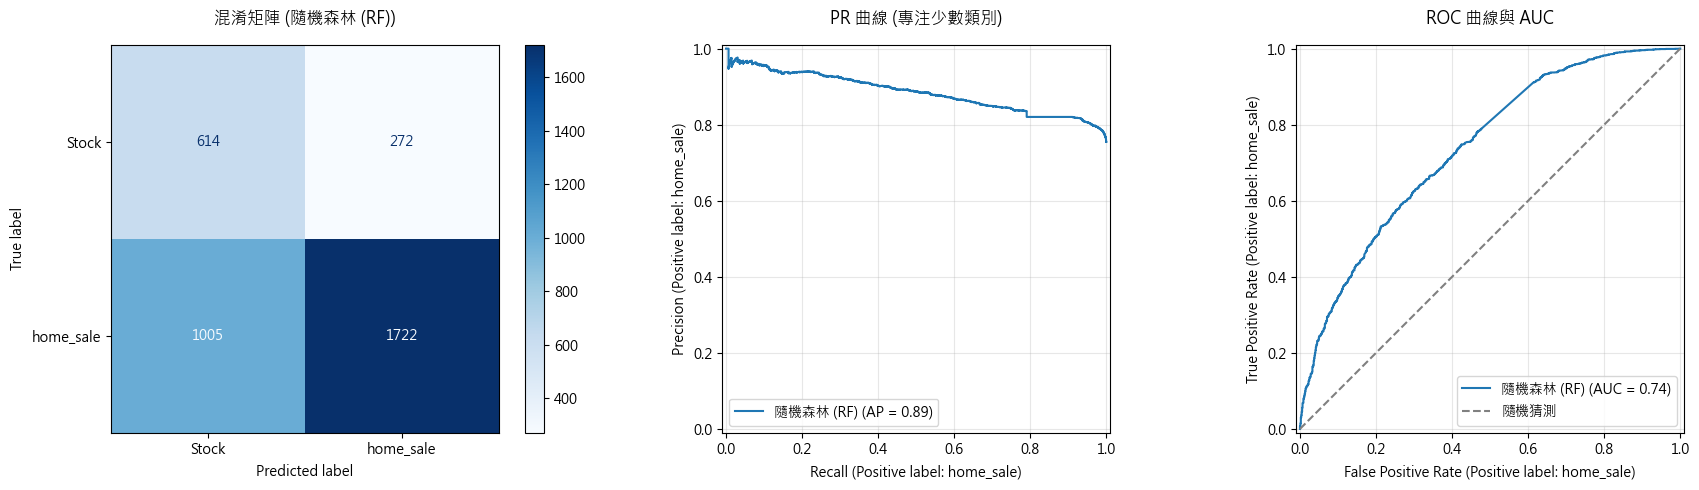


<<< 隨機森林認定的 Top 20 關鍵特徵 (不分板塊) >>>
炒房              (重要度: 0.0323)
恭喜              (重要度: 0.0158)
自己              (重要度: 0.0155)
真的              (重要度: 0.0128)
火車頭             (重要度: 0.0109)
房價              (重要度: 0.0099)
水龍頭             (重要度: 0.0099)
可能              (重要度: 0.0098)
不是              (重要度: 0.0094)
現在              (重要度: 0.0091)
條件              (重要度: 0.0087)
空空              (重要度: 0.0086)
金主              (重要度: 0.0086)
台灣              (重要度: 0.0085)
新青安             (重要度: 0.0084)
買房              (重要度: 0.0082)
營建股             (重要度: 0.0080)
建商              (重要度: 0.0077)
本來              (重要度: 0.0075)
很多              (重要度: 0.0068)


In [19]:
# 1. 向量化 (RF 專用)
vectorizer_rf = TfidfVectorizer(
    ngram_range=(1, 2), 
    max_features=5000, 
    min_df=5,
    stop_words=final_stop_words,
    #token_pattern=r"(?u)\b[^\d\W]+\b"
)

# 轉換資料 (使用之前的 X_train, X_test 原始文字資料)
X_train_tfidf_rf = vectorizer_rf.fit_transform(X_train)
X_test_tfidf_rf = vectorizer_rf.transform(X_test)

# 2. 訓練模型
rf_clf = RandomForestClassifier(
    n_estimators=200, # 森林中樹的數量
    max_depth=40,       
    class_weight='balanced', # 解決類別不平衡問題
    n_jobs=-1,  # -1: 使用所有 CPU 核心加速運算
    random_state=42
)
print("開始訓練隨機森林模型...")
rf_clf.fit(X_train_tfidf_rf, y_train)

# 進行預測與評估
y_pred_rf = rf_clf.predict(X_test_tfidf_rf)

# 3. 呼叫共用函式產生報表與圖表
evaluate_model(rf_clf, X_test_tfidf_rf, y_test, y_pred_rf, "隨機森林 (RF)")

# 查看隨機森林認定的「重要特徵」
# 注意：隨機森林給的是 Feature Importance (0~1)，沒有正負號 (不分哪一類)
def get_rf_importance(vectorizer, clf, n=30):
    feature_names = vectorizer.get_feature_names_out()
    importances = clf.feature_importances_
    
    # 取得排序索引 (從大到小)
    indices = np.argsort(importances)[::-1]
    
    top_features = [(feature_names[i], importances[i]) for i in indices[:n]]
    return top_features

rf_top_20 = get_rf_importance(vectorizer_rf, rf_clf, 20)

print("\n<<< 隨機森林認定的 Top 20 關鍵特徵 (不分板塊) >>>")
for word, score in rf_top_20:
    print(f"{word:15} (重要度: {score:.4f})")

##### 結果

- accuracy 0.65；Stock 的 P/R/F1 = 0.38/0.69/0.49。.
- recall 比 LR 略低（0.69 vs 0.70），precision 低到 0.38，造成整體準確率掉到 0.65。
- 代表「抓得到不少 Stock，但誤報更多」。
- 在這份高維稀疏文字特徵（TF-IDF）上，RF 明顯不如線性模型穩定。

### 3.8 Linear SVC 比較模型

- 功能：訓練 class_weight=balanced 的 LinearSVC 並評估。
- 目的：測試最大間隔分類器能否改善少數類別。
- 線性邊界、對高維稀疏資料友善，但可解釋性低於 LR。

Linear SVC 的核心目標是在高維度空間中尋找一條「最寬的決策邊界（Margin）」。特別擅長忽略遠離邊界的雜訊，來進行分類切割。


=== Linear SVC 模型 準確度報告 ===
              precision    recall  f1-score   support

       Stock       0.44      0.67      0.53       886
   home_sale       0.87      0.72      0.79      2727

    accuracy                           0.71      3613
   macro avg       0.66      0.70      0.66      3613
weighted avg       0.77      0.71      0.73      3613



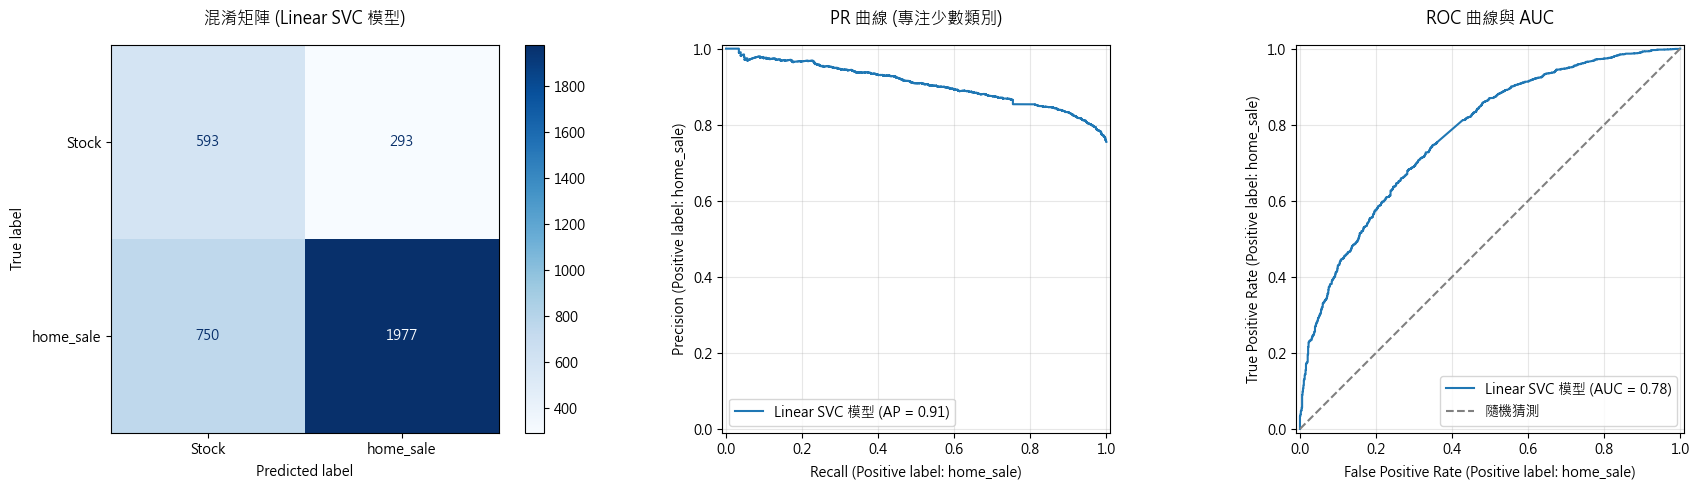

In [21]:
# --- 測試 1: LinearSVC (線性支持向量機) ---
# class_weight='balanced' 依然是必備的
clf_svc = LinearSVC(class_weight='balanced', max_iter=2000, random_state=42)
clf_svc.fit(X_train_tfidf, y_train)
y_pred_svc = clf_svc.predict(X_test_tfidf)
evaluate_model(clf_svc, X_test_tfidf, y_test, y_pred_svc, "Linear SVC 模型")


##### 結果

- accuracy 0.71；Stock 的 P/R/F1 = 0.44/0.67/0.53。
- 整體略低於 LR（0.71 vs 0.72），Stock precision/recall 也沒有超越 LR。
- 說明即便用 margin-based 線性分類器，對「兩板詞彙重疊」問題改善有限。並非「演算法切割能力不足」的問題，而是「特徵空間重疊」。
- 當兩板鄉民使用完全相同的詞彙（如：政府、房價）時，這些詞在空間中的座標是完全重疊的，無法完美切分。
- 實務上若重視可解釋性，LR 會比 SVC 更有優勢。


### 3.9 Complement Naive Bayes 比較模型

- 功能：訓練 CNB 並評估。
- 目的：測試在不平衡文本分類中，CNB 是否有優勢。
- 對詞頻型特徵與類別不平衡具有實務韌性。

一般的單純貝氏模型在面對資料不平衡（如本案 3:1）時，極易產生嚴重偏誤，傾向將多數文章都判定為房板。

為了解決此問題，測試使用「互補單純貝氏（ComplementNB）」：與其計算文章「有多像股板」，它改為計算文章「有多『不像』房板」的這種反向權重計算。


=== 互補單純貝氏 (ComplementNB) 準確度報告 ===
              precision    recall  f1-score   support

       Stock       0.48      0.67      0.56       886
   home_sale       0.88      0.77      0.82      2727

    accuracy                           0.74      3613
   macro avg       0.68      0.72      0.69      3613
weighted avg       0.78      0.74      0.76      3613



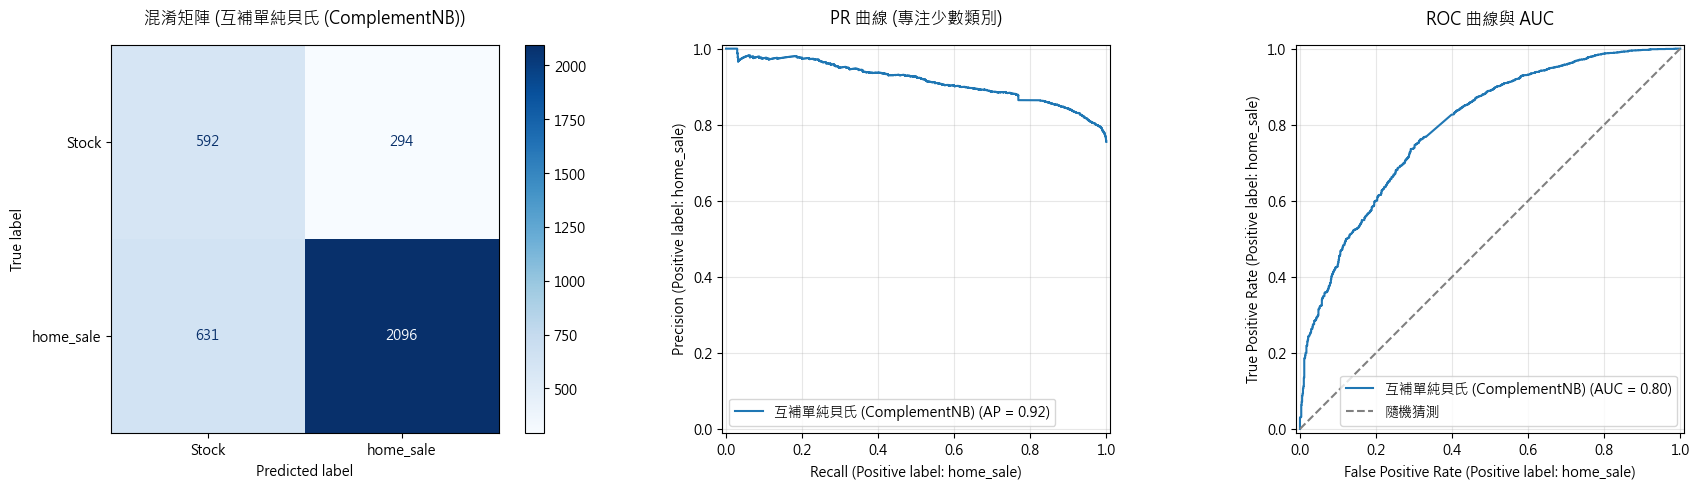

In [22]:
# --- 測試 2: Complement Naive Bayes (互補單純貝氏) ---
# NB 模型不需要設定 class_weight，因為它的演算法本身就是在對抗不平衡
clf_cnb = ComplementNB()
clf_cnb.fit(X_train_tfidf, y_train)
y_pred_cnb = clf_cnb.predict(X_test_tfidf)
evaluate_model(clf_cnb, X_test_tfidf, y_test, y_pred_cnb, "互補單純貝氏 (ComplementNB)")

##### 結果

- accuracy 0.74 (最高)；Stock 的 P/R/F1 = 0.48/0.67/0.56。
- Stock 指標與 LR 非常接近，甚至 precision 略高(0.48 vs 0.47)。
- 多數類別（房板）抓得更準，但股板的 Precision 依然卡在 0.48 的天花板。
- 若首要目標是「整體分類效能 + 對不平衡資料的穩健」，CNB 是值得保留的候選主模型。
- 當四種截然不同的演算法（LR, RF, SVC, CNB）在股板 Precision 上皆收斂於 0.45 左右時，交叉驗證了純詞頻（Bag-of-Words）模型已達到物理極限，無法僅靠演算法的更換來突破跨領域語意的盲區。


In [23]:
cnb_errors = get_high_confidence_errors(
    clf_cnb, 
    X_test_tfidf, 
    y_test,
    texts=X_test,
    target_actual='home_sale', 
    target_pred_label='Stock', 
    threshold=0.8
)
#pd.set_option('display.max_colwidth', 100) # 設定 Pandas 顯示文字的長度
#print(errors[['content', 'actual', 'Stock']].head(10))
print('實際為房板，被判斷成股板')
for idx, row in cnb_errors.head(10).iterrows():
    print(f"--- 信心值: {row['Stock']:.4f} ---")
    print(f"內容摘要: {row['content'][:250]}...") # 只看前 200 字
    print("-" * 50)

實際為房板，被判斷成股板
--- 信心值: 0.9735 ---
內容摘要: 房仲 大勝 經濟 火車頭 啟動 ~~...
--------------------------------------------------
--- 信心值: 0.9643 ---
內容摘要: 反觀 台灣 經濟 火車頭 嘻嘻...
--------------------------------------------------
--- 信心值: 0.9444 ---
內容摘要: 丸子...
--------------------------------------------------
--- 信心值: 0.9245 ---
內容摘要: 因為 不是 法律 不是 行政 命令 兩者 管道 救濟 央行 獨立性 缺點 這樣 美國 FED 現在 一樣 弊端...
--------------------------------------------------
--- 信心值: 0.9082 ---
內容摘要: 不要 鬆好 搓完 丸子...
--------------------------------------------------
--- 信心值: 0.9071 ---
內容摘要: 水龍頭 打開...
--------------------------------------------------
--- 信心值: 0.9031 ---
內容摘要: 台灣 央行 獨立 機構 央行 行政院 管轄 單位...
--------------------------------------------------
--- 信心值: 0.8983 ---
內容摘要: 全力 炒房...
--------------------------------------------------
--- 信心值: 0.8956 ---
內容摘要: 金融股 驚驚 漲啪...
--------------------------------------------------
--- 信心值: 0.8799 ---
內容摘要: 畢竟 炒房 OO...
--------------------------------------------------


### 3.10 LSA(TruncatedSVD) + SVC

- 功能：先把 TF-IDF 降到 800 維語意主題，再接 LinearSVC。
- 目的：測試語意壓縮是否改善跨領域語意重疊。
- 由「字面詞」轉「潛在語意」；在本資料反而喪失關鍵黑話訊號。

為了突破 TF-IDF 將每個詞彙視為獨立維度的限制，測試潛在語意分析（LSA, TruncatedSVD）。試圖找出字詞之間的共現關係，將 5000 個獨立的詞彙壓縮成800潛在主題（例如將「建商、營造、工地」壓縮為「營建概念」），藉此幫助模型理解抽象語意。

正在訓練 LSA (潛在語意) + SVC 模型...
=== LSA 潛在語意模型 準確度報告 ===
              precision    recall  f1-score   support

       Stock       0.44      0.73      0.55       886
   home_sale       0.89      0.70      0.78      2727

    accuracy                           0.70      3613
   macro avg       0.66      0.71      0.66      3613
weighted avg       0.78      0.70      0.72      3613



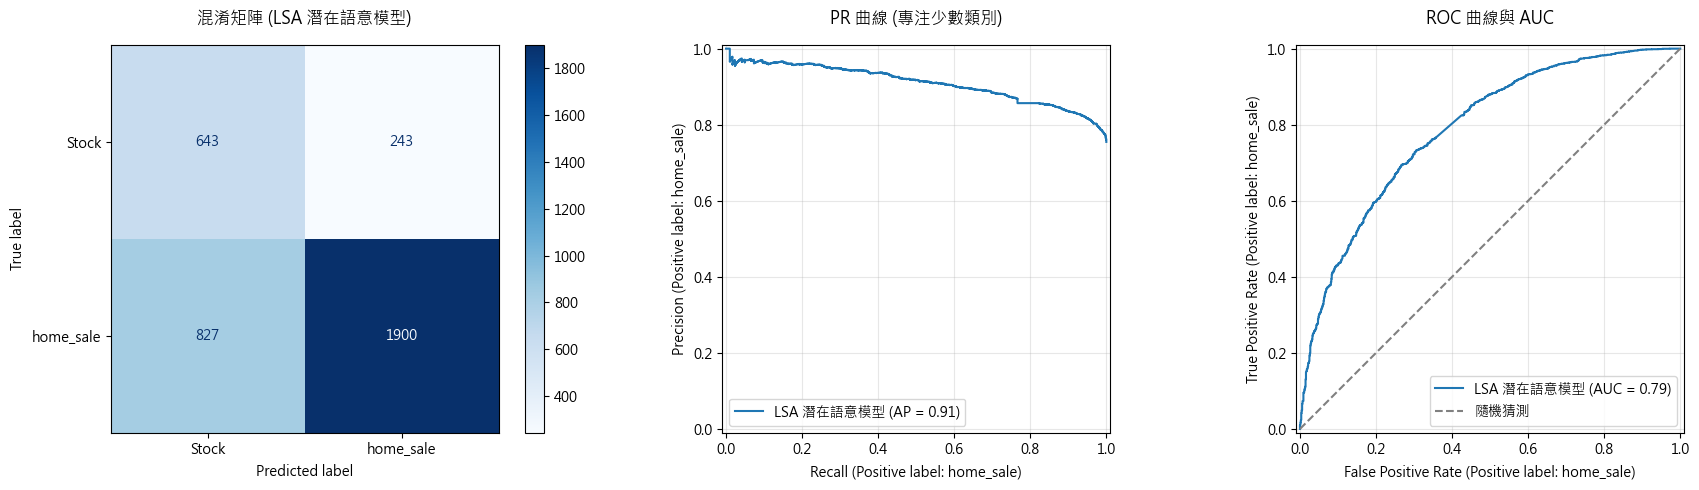

In [24]:
# 1. 建立 LSA 降維器 (將 5000 維的 TF-IDF 壓縮成 500 個潛在主題)
svd = TruncatedSVD(n_components=800, random_state=42)

# 2. 將 SVC 接在 LSA 後面
clf_lsa_svc = LinearSVC(class_weight='balanced', max_iter=2000, random_state=42)

# 3. 建立 Pipeline 讓資料順暢流動
lsa_pipeline = make_pipeline(svd, clf_lsa_svc)

print("正在訓練 LSA (潛在語意) + SVC 模型...")
lsa_pipeline.fit(X_train_tfidf, y_train)
y_pred_lsa = lsa_pipeline.predict(X_test_tfidf)

# 呼叫共用函式 (注意傳入的是 X_test_tfidf_pro，Pipeline 會自動做 SVD 轉換)
evaluate_model(lsa_pipeline, X_test_tfidf, y_test, y_pred_lsa, "LSA 潛在語意模型")

##### 結果
- accuracy 0.70；Stock 的 P/R/F1 = 0.44/0.73/0.55。.
- accuracy較 LR 略低（0.70 vs 0.73），Stock的precision 也略低 (0.44 vs 0.46)。
- 語意降維（LSA）在這裡可能把「黑話、細粒度詞訊號」一起壓掉，造成可分性下降
-  PTT 文本的「特徵模糊化（Feature Blurring）」：PTT 社群在不同板塊會有其特有的「黑話」與專有名詞（如：水龍頭、阿龍、空空）。LSA 的壓縮過程雖然提取了宏觀概念，卻會「平均」掉分類特徵。
- 在論壇短文本分析中，保留原始字詞的銳利度與顆粒度，比尋找抽象的語意概念更為重要。

### 3.11 結論

##### 模型成效比較（測試集 3613 筆）

| Model | Accuracy | Stock Precision | Stock Recall | Stock F1 |
| -- | :--: | :--: | :--: | :--: |
| Logistic Regression | 0.73 | 0.47 | 0.70 | 0.56 |
| Random Forest | 0.65 | 0.38 | 0.69 | 0.49 |
| Linear SVC | 0.71 | 0.44 | 0.67 | 0.53 |
| ComplementNB | 0.74 | 0.48 | 0.67 | 0.56 |
| LSA + SVC | 0.70 | 0.44 | 0.73 | 0.55 |


1. 整體成效：線性模型與貝氏模型表現略優
  * 從 **Accuracy (準確度)** 來看，**ComplementNB (CNB)** 以 **0.74** 略高於 **Logistic Regression (LR)** 的 **0.73**。
  * 解讀：這反映了在 PTT 這種詞彙特徵極強的資料集上，傳統的統計模型（線性與貝氏）表現較穩定。
  * CNB 在處理類別不平衡（Stock 樣本較少）的資料時可能具有一定優勢。

2. 關鍵痛點：高召回率 (Recall) 伴隨低精確度 (Precision)
  * 這是這份報告中最值得注意的現象：所有模型對 `Stock` 的 **Recall** 都在 **0.67 ~ 0.73** 之間，但 **Precision** 卻都低於 **0.5**。
  * 現象：模型能抓出大約七成的股板文章，但只要模型說它是股板，實際上有一半以上其實是房板。
  * 原因分析：
    * 資料不平衡與決策權衡： 由於房板樣本數為股板的三倍，在模型訓練時使用了類別權重平衡（Class Weighting）。使模型提高少數類別的預測傾向，雖成功使召回率（Recall）提升至 0.70，但也導致偽陽性（False Positives）增加，犧牲了精準度。
    * 基礎機率（Base Rate）稀釋效應： 在 3:1 的資料基數下，即使模型對多數類別（房板）僅有小比例的誤判，其絕對數量亦足以大幅稀釋少數類別（股板）的精準度。
    * 跨領域的語意重疊（Semantic Overlap）： 文本分析顯示，兩個社群在探討房市時，皆會頻繁使用總經與投資詞彙。當房板文章深入討論「央行政策、通膨或營建股表現」以佐證購屋決策時，線性模型容易因捕捉到高權重的金融特徵而產生誤判。突顯純詞頻（TF-IDF）模型在處理「跨領域同義文本」時的語意理解極限。

3. 模型個別表現診斷
  * Random Forest (隨機森林)：隨機森林在這次測試中表現墊底。
    * 原因：隨機森林在處理 TF-IDF 這種「高維度且稀疏」（幾萬個詞特徵，但每篇文只有幾十個詞）的資料時，容易迷失在雜訊中。它對 `Stock` 的 Precision 只有 **0.38**，代表它極度傾向於亂抓。
    * 樹模型不擅長處理「極度稀疏且高維」的線性可分問題，相較之下，線性模型更適合 TF-IDF 表示。
  * Linear SVC vs. LSA + SVC：
    * Linear SVC (0.71)：直接用原始特徵的效果尚可，但略遜於 LR。
    * LSA + SVC (0.70)：將原始高維 TF-IDF 特徵壓縮至 800 維，但 Accuracy 依然沒能超過直接跑模型，且 Recall (0.73) 雖然是最高，但也帶來了精確度的下降。
    * **降維過程可能損失部分具有區分力的細節資訊。**

4. 結論（綜合解讀）
  * **模型整體表現**
    各模型之間差距不大，其中 **Logistic Regression 與 ComplementNB 表現較為穩定**，可視為本任務中較可靠的基準模型。隨機森林則因不適合高維稀疏特徵，整體表現明顯較弱。

  * **Precision 與 Recall 的結構性權衡**
    所有模型皆呈現「**Recall 高、Precision 低**」的現象，顯示在類別不平衡（3:1）與 class weighting 設定下，模型傾向提高少數類別（Stock）的涵蓋率，但同時增加誤判。此為不平衡分類任務中的典型 trade-off。

  * **語意重疊對分類的限制**
    房板與股板在討論房市議題時存在明顯語意重疊（如政策、房價、投資相關詞彙），使得僅依賴 TF-IDF 的詞頻特徵時，模型較難有效區分跨領域文本，進而影響 precision 表現。

  * **特徵工程（停用詞處理）對不同模型的影響差異**
    實驗顯示，調整過濾詞（停用詞）會對模型產生不同影響：

    * 對 **Logistic Regression（線性模型）** 而言，移除過多語氣詞（如「真的」、「其實」、「現在」）會使 precision 下降，顯示這些詞雖非主題詞，仍包含可用的分類訊號（例如語氣或社群風格）。
    * 對 **部分非線性模型** 而言，適度移除停用詞可降低雜訊，反而有助於 precision 提升。
    * 這說明停用詞不應僅依語意直覺刪除，而需依模型特性與實驗結果調整。
  * **TF-IDF 特徵的再解讀**
    分析顯示，部分高權重詞（如「真的」、「現在」）在特定社群中具有顯著差異，反映的不只是主題內容，也包含語言風格。因此，**分類器實際學習的不僅是「談什麼」，也包含「如何表達」**。

  * **整體結論**
    * 本研究顯示，在不平衡且語意重疊的文本分類任務中，模型表現不僅取決於演算法本身，也高度依賴特徵工程與語料特性。相較於單純提升模型複雜度，理解特徵在不同模型中的作用更為關鍵。
    * 本研究資料來自同一論壇下的不同板塊，語料同時包含共通語言與板塊特有用語。即使為跨板共用詞彙，其在不同板塊中的出現分布差異，仍可成為有效的分類訊號，使模型同時學習主題內容與語言風格。
    * 此結果說明，語氣詞等「弱語意特徵」不應僅依直覺移除，而應依其在不同類別中的統計分布與模型特性進行判斷。
    * 然而，由於模型部分依賴社群特有語言風格進行分類，當資料來源或語境改變時，相關特徵可能失效，進而影響模型的泛化能力。因此，本研究結果主要適用於相同語域（domain）下的分類任務。


## 4. 尋找最佳參數

在初步的模型成效對照中，Logistic Regression (LR) 與 ComplementNB (CNB) 準確度約落在 0.73 左右。選擇這兩個模型進行參數最佳化（GridSearch），主要基於以下三大原因：

1. 績效基準較高：兩者目前表現相對較佳。相較於表現較差的模型（如隨機森林），優先針對這兩個模型進行調整，較有機會進一步提升整體表現。
2. 運算效率佳：相對於支援向量機（SVC）或隨機森林，LR 與 CNB 的運算速度較快，使得在網格搜尋中可以測試更多參數組合，而不致造成過長的計算時間。
3. 適合高維稀疏特徵：LR 與 CNB 皆適合處理 TF-IDF 所產生的高維稀疏矩陣。LR 能捕捉全域線性關係，而 CNB 在處理類別不平衡資料時通常表現穩定，兩者皆能對應本研究資料特性。

模型目標：
1. Accuracy ≥ 0.70：確保模型在整體分類上維持基本穩定性，避免因過度偏向少數類別（Stock）而影響多數類別（home_sale）的預測表現。
2. Precision ≥ 0.55：改善模型對少數類別的預測準確性，降低 False Positive，提升預測為股板時的可信度。
3. Recall ≥ 0.50：相較於原本 Recall 約 0.70 但伴隨較高誤判的情況，此設定允許模型在降低誤判的同時，接受部分少數類別樣本被忽略。
4. 0.60 ≥ F1 ≥ 0.55：作為 Precision 與 Recall 的平衡指標，若 Precision 與 Recall 均有所調整，F1 可反映較均衡的分類表現。

In [27]:
start = time.time()
# 1. 定義模型的 Pipeline 與對應的參數網格
model_configs = [
    {
        'name': 'Logistic Regression',
        'pipeline': Pipeline([
            ('tfidf', TfidfVectorizer(stop_words=final_stop_words)),
            ('clf', LogisticRegression(max_iter=2000))
        ]),
        'param_grid': [
            # 組合一：針對 liblinear (支援 L1, L2)
            {
                'tfidf__max_features': [5000, 10000, None],    # None 代表不限制，保留所有詞
                'tfidf__ngram_range': [(1,1), (1, 2), (1, 3)], # 測試單詞、雙詞組、三詞組
                'tfidf__min_df': [3, 5],                       # 詞組至少要在 3 或 5 篇文章中出現過，過濾極端罕見詞
                'clf__C': [0.1, 1.0, 10.0],                    # 測試不同的懲罰係數
                'clf__solver': ['liblinear'],                  # 測試不同的最佳化演算法
                'clf__penalty': ['l1', 'l2'],
                #'clf__solver': ['saga'],  # 推薦改用 saga，它支援所有正規化方式且更現代
                #'clf__l1_ratio': [0, 1],  # 0 等於 l2, 1 等於 l1
                'clf__class_weight': [None, 'balanced', {'Stock': 1.5, 'home_sale': 1.0}, {'Stock': 2.0, 'home_sale': 1.0}],
                                      # None:  1:1 不加權 (最有利於 Precision, 但 Recall 會降)
                                      # balanced: 原本的 1:3 激進配置 (Recall 高, Precision 低)
                                      # 1:1.5 溫和配置 (更傾向於穩定 Accuracy)                      
                                      # 1:2 中庸配置 (試圖平衡 Precision 與 Recall)
            },
            # 組合二：針對 lbfgs (僅支援 L2)
            {
                'tfidf__max_features': [5000, 10000, None],
                'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)],
                'tfidf__min_df': [3, 5],
                'clf__C': [0.1, 1.0, 10.0],
                'clf__solver': ['lbfgs'],
                'clf__penalty': ['l2'],
                #'clf__l1_ratio': [0],  # 用 l1_ratio=0 取代 penalty='l2'
                'clf__class_weight': [None, 'balanced', {'Stock': 1.5, 'home_sale': 1.0}, {'Stock': 2.0, 'home_sale': 1.0}]
            }
        ]
    },
    {
        'name': 'ComplementNB',
        'pipeline': Pipeline([
            ('tfidf', TfidfVectorizer(stop_words=final_stop_words)),
            ('clf', ComplementNB())
        ]),
        'param_grid': {
            'tfidf__max_features': [5000, 10000, None],
            'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)],
            'tfidf__min_df': [3, 5],
            'clf__alpha': [0.1, 0.5, 1.0, 2.0]           # 測試不同的平滑參數
        }
    }
]

# 2. 執行迴圈進行網格搜尋
best_models = {}

print("開始模型最佳化...")

for config in model_configs:
    print(f"\n正在訓練與最佳化: {config['name']}...")
    
    grid_search = GridSearchCV(
        estimator=config['pipeline'],
        param_grid=config['param_grid'],
        cv=5, 
        scoring='f1_macro',
        n_jobs=-1, # 使用所有 CPU 核心加速運算
        verbose=1  # 顯示運算進度
    )
    
    # 傳入尚未處理過的原始文本資料
    grid_search.fit(X_train, y_train)
    
    best_models[config['name']] = grid_search.best_estimator_
    
    print(f"最佳 F1-macro 分數: {grid_search.best_score_:.4f}")
    print(f"最佳參數組合:")
    for param_name, param_value in grid_search.best_params_.items():
        print(f"  {param_name}: {param_value}")

# 3. 取得最佳模型並進行預測 (假設我們要拿 LR 來預測測試集)
print("\n--- 預測階段 ---")
best_lr_model = best_models['Logistic Regression']

# 直接將原始測試文本丟入 pipeline，它會自動進行 Tfidf -> Predict
y_pred_lr = best_lr_model.predict(X_test)

end = time.time()
print('完成, time costing: {}'.format(end - start))

開始模型最佳化...

正在訓練與最佳化: Logistic Regression...
Fitting 5 folds for each of 648 candidates, totalling 3240 fits


D:\git\python_homework\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


最佳 F1-macro 分數: 0.6962
最佳參數組合:
  clf__C: 1.0
  clf__class_weight: {'Stock': 2.0, 'home_sale': 1.0}
  clf__penalty: l2
  clf__solver: lbfgs
  tfidf__max_features: 10000
  tfidf__min_df: 3
  tfidf__ngram_range: (1, 2)

正在訓練與最佳化: ComplementNB...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
最佳 F1-macro 分數: 0.6945
最佳參數組合:
  clf__alpha: 1.0
  tfidf__max_features: 10000
  tfidf__min_df: 3
  tfidf__ngram_range: (1, 3)

--- 預測階段 ---
完成, time costing: 358.3330364227295


- GridSearch 結果顯示，ComplementNB 最佳 n-gram 為 (1,3)，而 Logistic Regression 則為 (1,2)。此差異反映兩種模型對特徵的使用方式不同。
- ComplementNB 作為機率模型，偏好語意明確且具有高區分力的特徵，trigram（如固定片語）雖出現頻率較低，但在特定類別中具有高度代表性，能有效提升分類效果。
- 相對地，Logistic Regression 為線性模型，依賴多個特徵的加權組合進行判斷。由於 trigram 特徵較為稀疏且覆蓋率低，容易影響模型穩定性與泛化能力，因此以 unigram 與 bigram 的組合較能取得穩定表現。
- 此結果顯示，不同模型對特徵粒度的偏好存在差異，應依模型特性選擇適當的 n-gram 範圍。

=== 最終最佳化模型 (LR) 評估報告 ===
=== Logistic Regression (Best Params) 準確度報告 ===
              precision    recall  f1-score   support

       Stock       0.62      0.52      0.57       886
   home_sale       0.85      0.90      0.87      2727

    accuracy                           0.80      3613
   macro avg       0.74      0.71      0.72      3613
weighted avg       0.80      0.80      0.80      3613



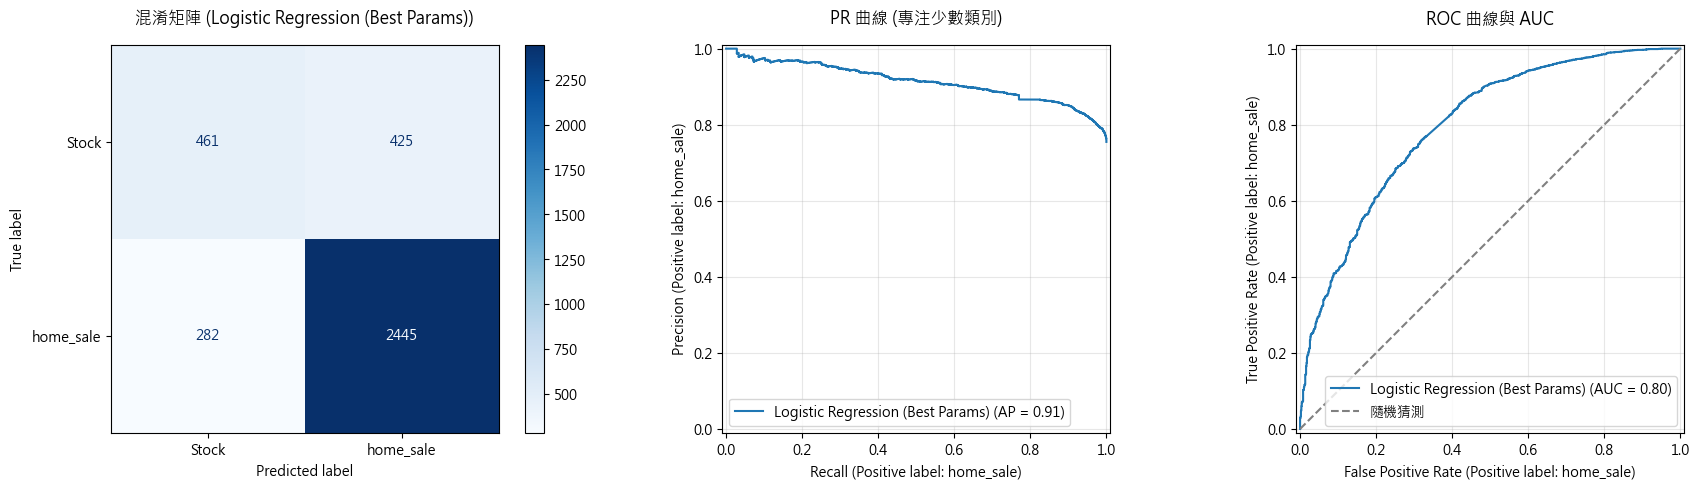


<<< 傾向判定為 Stock 的最強關鍵詞 >>>
炒房              (權重: -3.4007)
營建              (權重: -3.3540)
營建股             (權重: -3.1828)
金主              (權重: -3.1185)
火車頭             (權重: -3.0992)
水龍頭             (權重: -3.0367)
天條              (權重: -3.0263)
金管會             (權重: -2.5809)
法律              (權重: -2.5389)
獨立              (權重: -2.5353)
獨立性             (權重: -2.5225)
不同              (權重: -2.4766)
丸子              (權重: -2.4030)
泡泡              (權重: -2.3719)
銀行法             (權重: -2.3640)
洩洪              (權重: -2.3578)
韌性              (權重: -2.3404)
台電              (權重: -2.3391)
貸貸相傳            (權重: -2.2835)
50年             (權重: -2.2228)
違法              (權重: -2.1733)
炸彈              (權重: -2.1713)
認賠              (權重: -2.1432)
政客              (權重: -2.1034)
真話              (權重: -2.0907)
爆掉              (權重: -2.0701)
泡沫              (權重: -2.0266)
時空背景            (權重: -2.0156)
華固              (權重: -2.0098)
吸毒              (權重: -1.9933)

<<< 傾向判定為 home_sale 的最強關鍵詞 >>>
恭喜              (權重: 3.1511)
空空         

In [30]:
# 1. 取得最佳 LR 模型 (它已經包含 Tfidf -> LR 的所有最佳參數)
final_lr_model = best_models['Logistic Regression']

# 2. 對原始測試集進行預測 (X_test 應為原始文字)
y_pred_final = final_lr_model.predict(X_test)

# 3. 呼叫你的評估函式
print("=== 最終最佳化模型 (LR) 評估報告 ===")
evaluate_model(
    final_lr_model, 
    X_test,            # 注意：這裡直接丟原始文字，因為 pipeline 裡有 tfidf
    y_test, 
    y_pred_final, 
    "Logistic Regression (Best Params)"
)

# 1. 透過 named_steps 萃取出訓練好的 Vectorizer 與 Classifier
best_vectorizer = best_lr_model.named_steps['tfidf']
best_classifier = best_lr_model.named_steps['clf']

# 2. 將萃取出來的元件放入您的函數中
# 注意：第二個參數應該放萃取出來的 best_classifier，而不是整個 Pipeline
labels, top_0, top_1 = get_model_importance(best_vectorizer, best_classifier, 30)

print(f"\n<<< 傾向判定為 {labels[0]} 的最強關鍵詞 >>>")
for word, score in top_0:
    print(f"{word:15} (權重: {score:.4f})")

print(f"\n<<< 傾向判定為 {labels[1]} 的最強關鍵詞 >>>")
for word, score in top_1:
    print(f"{word:15} (權重: {score:.4f})")


=== 最終最佳化模型 (CNB) 評估報告 ===
=== ComplementNB (Best Params) 準確度報告 ===
              precision    recall  f1-score   support

       Stock       0.51      0.57      0.54       886
   home_sale       0.86      0.82      0.84      2727

    accuracy                           0.76      3613
   macro avg       0.68      0.70      0.69      3613
weighted avg       0.77      0.76      0.77      3613



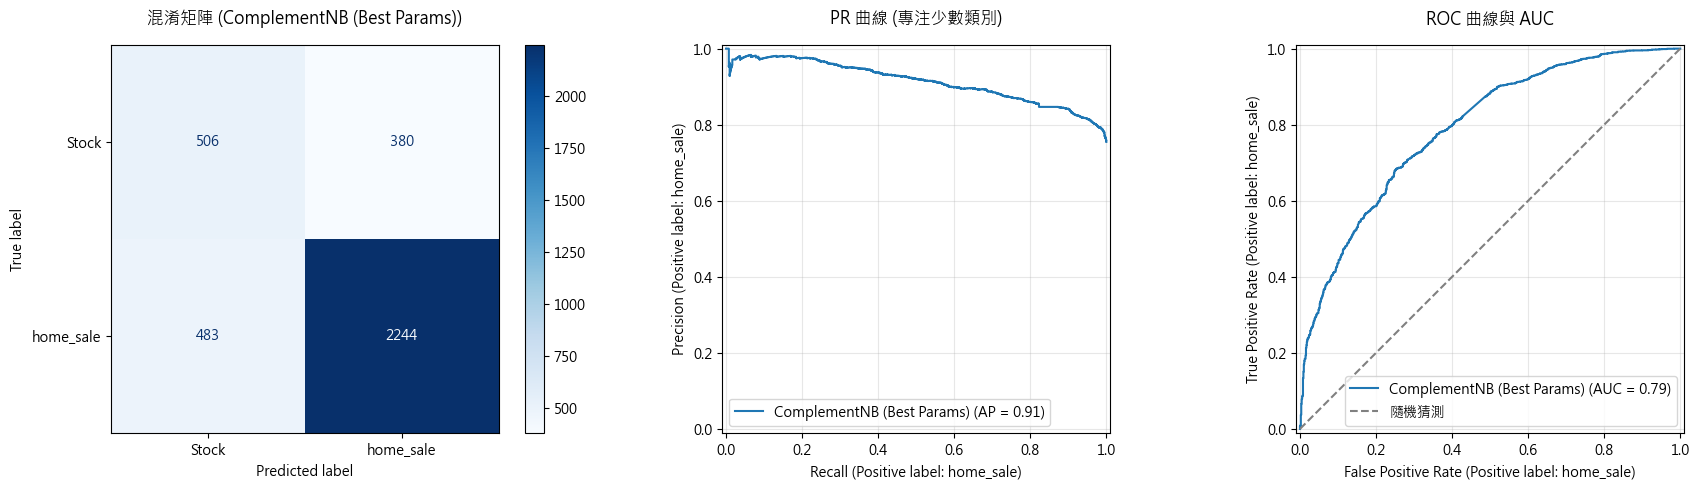


<<< 傾向判定為 Stock 的最強關鍵詞 >>>
貸貸相傳            (權重: -2.8865)
經濟 火車頭          (權重: -2.8266)
洩洪              (權重: -2.8112)
時空背景 不同         (權重: -2.8010)
丸子              (權重: -2.6882)
任性              (權重: -2.6092)
垃圾黨             (權重: -2.5802)
火車頭             (權重: -2.5729)
營建              (權重: -2.4647)
呆丸              (權重: -2.4267)
時空背景            (權重: -2.4168)
房價 不會 不要        (權重: -2.4014)
台電              (權重: -2.4004)
天條              (權重: -2.3911)
無視 法律           (權重: -2.3819)
你媽              (權重: -2.3292)
不會 不要           (權重: -2.3283)
炒房 時代           (權重: -2.2647)
真話              (權重: -2.2238)
金主              (權重: -2.1955)
還是 炒房           (權重: -2.1697)
遵守              (權重: -2.1486)
政治 獻金           (權重: -2.1449)
獻金              (權重: -2.1386)
絕子絕孫            (權重: -2.1341)
韌性              (權重: -2.1102)
房蟲 開心           (權重: -2.0935)
泡泡              (權重: -2.0837)
特別 預算           (權重: -2.0791)
衝衝              (權重: -2.0142)

<<< 傾向判定為 home_sale 的最強關鍵詞 >>>
恭喜              (權重: 3.2545)
多多         

In [31]:
# 1. 從字典中提取最強的 CNB 模型
best_cnb_model = best_models['ComplementNB']

# 2. 進行預測
y_pred_cnb_final = best_cnb_model.predict(X_test)

# 3. 評估與印出報告
print("=== 最終最佳化模型 (CNB) 評估報告 ===")
evaluate_model(
    best_cnb_model, 
    X_test, 
    y_test, 
    y_pred_cnb_final, 
    "ComplementNB (Best Params)"
)

# 1. 透過 named_steps 萃取出訓練好的 Vectorizer 與 Classifier
best_vectorizer = best_cnb_model.named_steps['tfidf']
best_classifier = best_cnb_model.named_steps['clf']

# 2. 將萃取出來的元件放入您的函數中
labels, top_0, top_1 = get_model_importance(best_vectorizer, best_classifier, 30)


print(f"\n<<< 傾向判定為 {labels[0]} 的最強關鍵詞 >>>")
for word, score in top_0:
    print(f"{word:15} (權重: {score:.4f})")

print(f"\n<<< 傾向判定為 {labels[1]} 的最強關鍵詞 >>>")
for word, score in top_1:
    print(f"{word:15} (權重: {score:.4f})")

- 模型權重分析顯示，ComplementNB 所選出的特徵詞多為語意明確的主題詞或關鍵片語（如「營建股」、「經濟 火車頭」、「政治 獻金」），具有較高的可解釋性。然而，Logistic Regression 除了捕捉主題詞外，亦對部分語氣詞與表達習慣（如「可能」、「但是」、「本來」）賦予權重，顯示其能整合多個弱特徵作為分類依據。
- 在房板與股板語意高度重疊的情境下，僅依賴主題詞往往不足以有效區分文本，而語言風格差異（如敘事方式與語氣）成為額外的重要訊號。因此，Logistic Regression 雖在特徵解釋性上較為分散，但整體分類表現優於 ComplementNB，反映出其在整合多元特徵上的優勢。
- ComplementNB 模型建立於特徵條件獨立的假設之上，然而在實際文本資料中，詞彙之間往往存在共現關係（例如「房價」、「貸款」、「利率」常同時出現），此假設並不完全成立。當特徵之間具有相關性時，模型可能重複計算部分證據，影響機率估計的準確性。
- 此外，本研究資料中除主題詞外，亦包含大量語氣與風格相關的弱特徵，這類特徵通常需透過多個詞的組合才能形成有效訊號。由於 Naive Bayes 無法建模特徵之間的交互關係，較難有效利用此類資訊，可能是其整體表現略遜於 Logistic Regression 的原因之一。

#### 結果

| 評估指標 | 目標值 | LR (最佳參數) | CNB (最佳參數) |
| -- | :--: |:--: |:--: |
| Accuracy | >= 0.70 | 0.80 | 0.76 |
| Stock Precision | >= 0.55 | 0.62 | 0.51 |
| Stock Recall | >= 0.50 | 0.52 | 0.57 | 
| Stock F1-score | >= 0.55 | 0.57 | 0.54 |


- 經由多模型比較與 GridSearchCV，最終選擇 **Logistic Regression** 作為本研究之主要模型，其在 Precision 與整體表現上較為平衡。
- ComplementNB 模型雖經最佳化，在 Recall（0.57）上表現較佳，但 Precision（0.51）相對較低，顯示其較傾向預測為少數類別（Stock），導致誤判增加，因此未作為最終模型。
- 在未採用降維技術（SVD）並保留原始 TF-IDF 特徵的前提下，最終模型達成專案預設目標：
  * 整體準確度（Accuracy）提升至 **0.80**（目標設定 > 0.70）
  * 股板預測精確度（Stock Precision）提升至 **0.62**（目標設定 > 0.55），有效降低將房板文章誤判為股板的比例
- 關鍵策略與成效分析：
  1. **特徵工程：保留高維度與加入雙詞組 (Bigram)**
     * **結論**：透過排除低頻詞（`min_df=3`）並限制 n-gram 範圍，有助於控制特徵稀疏性，並降低過度擬合風險。
  2. **樣本不平衡處理：採用調整後的類別權重**
     * **分析**：原始資料集中股板與房板比例約為 1:3。使用 `class_weight='balanced'` 時，模型會提高對少數類別的預測傾向，雖可提升 Recall，但同時增加 False Positive，導致 Precision 降低（約 0.46）。
     * **結論**：將權重調整為 `{'Stock': 2.0, 'home_sale': 1.0}`，使模型在 Recall（0.52）與 Precision（0.62）之間取得較佳平衡。
  3. **演算法選擇：L2 正規化優於 L1 特徵選擇**
     * **分析**：比較 `liblinear`（L1）與 `lbfgs`（L2）後，L2 表現較佳。
     * **結論**：顯示在本任務中，分類結果較依賴多個弱特徵的累積效果，而非少數強特徵，L2 正規化能在保留資訊的同時抑制過大權重，表現較為穩定。
     * 實驗比較 liblinear（支援 L1/L2）與 lbfgs（僅支援 L2）後發現，L2 正規化搭配 lbfgs 表現最佳。這顯示本任務中分類依賴大量弱特徵的累積效果，L1 所帶來的特徵刪除反而可能損失重要資訊；而 lbfgs 能提供較穩定的最佳化結果，因此整體表現較佳。

## 5. 補充

### 模型泛化能力測試

使用相同條件，以TARFLOW拉取2026/03/21~2026/04/23的新資料對模型泛化能力做測試。

執行步驟：
1. 以相同模式對新資料做前處理
2. 斷詞與詞性標註
3. 以最佳化參數的LR模型分類
4. 以最佳化參數的CNB模型分類

In [ ]:
# === 2. 讀取並清理 CSV 資料 ===
df_a = pd.read_csv('./data/addition_basic_cleaned.csv')

# 剔除空值
df_a = df_a.dropna(subset=['content']).copy()

# 套用清理：由於網址與空白已在輸出 csv 前處理完畢，這裡直接套用同義詞轉換
df_a['cleaned_content'] = df_a['content'].apply(replace_synonyms)

# artCatagory每種各有幾筆
print(df_a['artCatagory'].value_counts())

df_a_test = df_a.copy()
text_to_segment_a = df_a_test['cleaned_content'].tolist()


artCatagory
home_sale    183
Stock         54
Name: count, dtype: int64


In [ ]:
#修改版1, 考慮詞性
print("開始執行 CKIPTagger 斷詞與詞性標註...")
start = time.time()
# 執行斷詞 (記得確保 ws 模型已經載入)
ws_results_a = ws(text_to_segment_a, coerce_dictionary=user_dict)
# 詞性標註
pos_results_a = pos(ws_results_a) 

end = time.time()
print('完成, time costing: {}'.format(end - start))

開始執行 CKIPTagger 斷詞與詞性標註...
完成, time costing: 23.31549382209778


In [ ]:
start = time.time()
final_segmented_texts_a = []

# 同時遍歷斷詞與詞性結果
for sentence_words, sentence_tags in zip(ws_results_a, pos_results_a):
    cleaned_words = []
    i = 0

    while i < len(sentence_words):
        word = sentence_words[i]
        tag = sentence_tags[i]

        # 數量詞 + 單位 合併
        if (
            i < len(sentence_words) - 1
            and is_number_like(word)
            and sentence_words[i + 1] in {"年", "月", "天", "分鐘", "日", "元", "萬", "億", "%", "次", "倍"}
        ):
            # 將數值與單位合併為一個詞
            word = word + sentence_words[i + 1]
            i += 2
        else:
            i += 1

        # 停用詞過濾
        if word in stop_words:
            continue

        # === 核心修改：利用詞性取代單純的單字過濾 ===
        # 解析 CKIP 的詞性標記
        is_noun = tag.startswith('N')  # 名詞類 (Na 普通名詞, Nb 專有名詞等)
        is_verb = tag.startswith('V')  # 動詞類 (VA, VC 等)
        is_adv = tag.startswith('D')   # 副詞類 (包含：不、沒、很、太)
        is_particle = tag.startswith('T') or tag.startswith('DE') # 語助詞或結構助詞 (的、了、吧)

        # 決定是否保留此詞的旗標
        keep_word = False
        
        # 條件 1：名詞與動詞通常是關鍵字主力，直接保留
        if is_noun or is_verb:
            keep_word = True
            
        # 條件 2：如果是副詞，且存在於 whitelist (例如裡面有 '不', '沒', '不要')
        # 這樣就能強行保住單個字的否定詞
        elif is_adv and word in whitelist:
            keep_word = True
            
        # 條件 3：其他未涵蓋的詞性，若長度 > 1 且不是無意義的助詞，則保留
        # 這可以確保合併出來的「數量+單位」(例如: 十年) 或其他複合詞能順利通關
        elif len(word) > 1 and not is_particle:
            keep_word = True

        if keep_word:
            cleaned_words.append(word)

    final_text = " ".join(cleaned_words)
    final_segmented_texts_a.append(final_text)

# 將結果存回測試用的 DataFrame
df_a_test['segmented_content'] = final_segmented_texts_a

# === 5. 檢視測試結果 ===
#for index, row in df_a_test.iterrows():
#    print(f"[{row['artCatagory']}]")
#    print("原文：", row['content'])
#    print("清整：", row['cleaned_content'])
#    print("斷詞：", row['segmented_content'])
#    print("=" * 50)
end = time.time()
print('完成, time costing: {}'.format(end - start))

完成, time costing: 0.06612086296081543


### 最佳化參數的LR模型

In [ ]:
df_a_test['final_content'] = df_a_test['segmented_content'].apply(filter_for_analysis)

# 1. 取得預測類別
y_new_pred = final_lr_model.predict(df_a_test['final_content'])

# 2. (選用) 取得預測機率，這對於查看模型「有多確定」很有幫助
y_new_proba = final_lr_model.predict_proba(df_a_test['final_content'])

# 假設 new_df['artCatagory'] 是正確答案
print("新資料預測報告(LR)：")
print(classification_report(df_a_test['artCatagory'], y_new_pred))


新資料預測報告(LR)：
              precision    recall  f1-score   support

       Stock       0.30      0.13      0.18        54
   home_sale       0.78      0.91      0.84       183

    accuracy                           0.73       237
   macro avg       0.54      0.52      0.51       237
weighted avg       0.67      0.73      0.69       237



### 最佳化參數的CNB模型

In [ ]:
# 1. 取得預測類別
y_new_cnb_pred = best_cnb_model.predict(df_a_test['final_content'])

# 2. (選用) 取得預測機率，這對於查看模型「有多確定」很有幫助
y_new_cnb_proba = best_cnb_model.predict_proba(df_a_test['final_content'])
print("新資料預測報告(CNB)：")
print(classification_report(df_a_test['artCatagory'], y_new_cnb_pred))


新資料預測報告(CNB)：
              precision    recall  f1-score   support

       Stock       0.63      0.69      0.65        54
   home_sale       0.90      0.88      0.89       183

    accuracy                           0.84       237
   macro avg       0.77      0.78      0.77       237
weighted avg       0.84      0.84      0.84       237



### 結論

- **跨資料測試與泛化能力觀察（補充分析）**

  為進一步評估模型的泛化能力，本研究以另一批新資料進行測試。結果顯示，Logistic Regression 在新資料上對 Stock 類別的 Recall 顯著下降（0.13），整體表現明顯劣化；相對地，ComplementNB 則維持較穩定的 Precision 與 Recall（Stock F1 = 0.65）。

  此現象顯示，不同模型對特徵的依賴方式會影響其跨資料表現。Logistic Regression 在原始資料中部分依賴語氣與表達風格等特徵，當資料分布改變時，相關訊號可能減弱，導致模型表現下降；而 ComplementNB 較依賴主題詞與固定語意片語，這類特徵在不同資料間相對穩定，因此具有較佳的泛化能力。

  此結果說明，在語言風格可能變動的應用場景中，僅依賴單一模型可能存在風險，未來可考慮結合不同特性的模型，以兼顧準確率與泛化能力。

## 6. 主題模型

In [24]:
import gensim
from gensim import corpora
import pyLDAvis
import pyLDAvis.gensim_models
import IPython

print("--- 開始準備 Gensim 格式資料 ---")
start = time.time()

# 手動加入過濾詞彙
extra_stops = ['不是','真的','什麼','自己','現在','趕快','可以','如果','應該','可能','其實','怎麼','還是','不會','一年','十年','20','因為','不要','繼續',
               '大家','沒有','所以','笑死','問題','哈哈','30','40','以上','不可能','絕對','這麼多','急了','覺得','這樣','一直','比較','明年','可憐','嘻嘻',
               '人家','多少','一樣','本來','這些','開始','時候','然後','知道','不用','這麼','是不是','很多','樓上','直接','看到','已經','其他','以前','不過',
               '不然','50','實際','根本','不能','==','最好']

final_stop_words = list(analysis_stop_words) + extra_stops

# 1. 斷詞與過濾 (假設 X_train 是一系列的字串)
texts = []
for doc in X_train:
    # 將字串用空白切分成 list，並做最後一道停用詞把關
    tokens = [word for word in str(doc).split() if word not in final_stop_words]
    texts.append(tokens)

# 2. 建立字典 (Dictionary)
dictionary = corpora.Dictionary(texts)

# 3. 過濾極端值 (這步等同於 scikit-learn 的 min_df 與 max_df，非常重要！)
# no_below=3: 詞彙至少要出現在 3 篇文章中
# no_above=0.5: 過濾掉出現在超過 50% 文章中的常見廢詞 (如：真的、這樣)
dictionary.filter_extremes(no_below=3, no_above=0.45)
print(f"字典建立完成，共保留 {len(dictionary)} 個有效詞彙。")

# 4. 建立語料庫 Corpus (Gensim 專屬的 DTM 格式：Bag of Words)
corpus = [dictionary.doc2bow(text) for text in texts]

print("--- 開始訓練 Gensim LDA 模型 ---")

# 5. 訓練 LDA 模型
n_topics = 5
lda_model = gensim.models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=n_topics,
    random_state=42,
    passes=15,          # 等同於 max_iter，訓練疊代次數
    alpha='auto',       # 讓模型自動學習文件的主題分佈
    eta='auto'          # 讓模型自動學習主題的詞彙分佈
)

# 印出文字版結果 (選用)
print("\n文字版主題關鍵字：")
for idx, topic in lda_model.print_topics(-1):
    print(f"主題 {idx + 1}: {topic}")

print("\n--- 產生 pyLDAvis 視覺化 ---")

# 6. 使用 pyLDAvis 進行互動式視覺化
# 確保在 Jupyter Notebook 環境下能顯示
pyLDAvis.enable_notebook()

# 準備視覺化資料
vis_data = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)

# 1. 將 vis_data 轉換成純 HTML 格式的字串
html_string = pyLDAvis.prepared_data_to_html(vis_data)

# 2. 透過 IPython 強制將 HTML 渲染在儲存格下方
IPython.display.display(IPython.display.HTML(html_string))

end = time.time()
print('完成, time costing: {}'.format(end - start))

--- 開始準備 Gensim 格式資料 ---
字典建立完成，共保留 6317 個有效詞彙。
--- 開始訓練 Gensim LDA 模型 ---

文字版主題關鍵字：
主題 1: 0.014*"房子" + 0.012*"40年" + 0.010*"空空" + 0.010*"便宜" + 0.009*"恭喜" + 0.009*"別人" + 0.008*"社宅" + 0.007*"30年" + 0.007*"買不起" + 0.006*"時間"
主題 2: 0.034*"買房" + 0.014*"房子" + 0.012*"小孩" + 0.011*"魯空" + 0.010*"有錢" + 0.009*"收入" + 0.008*"大概" + 0.007*"資產" + 0.007*"利息" + 0.007*"補助"
主題 3: 0.041*"銀行" + 0.023*"央行" + 0.018*"貸款" + 0.017*"炒房" + 0.016*"房貸" + 0.015*"利率" + 0.014*"政府" + 0.011*"條件" + 0.011*"政策" + 0.010*"風險"
主題 4: 0.042*"房價" + 0.026*"台灣" + 0.018*"房市" + 0.014*"房蟲" + 0.013*"投資" + 0.010*"股市" + 0.009*"自住" + 0.009*"股票" + 0.009*"房地產" + 0.009*"房板"
主題 5: 0.067*"新青安" + 0.024*"建商" + 0.019*"政府" + 0.010*"貸款" + 0.010*"之前" + 0.009*"政策" + 0.009*"一下" + 0.007*"不知道" + 0.007*"投資客" + 0.007*"年輕人"

--- 產生 pyLDAvis 視覺化 ---


完成, time costing: 241.74734902381897


### 解讀

#### 一、 視覺化空間分佈分析 (Intertopic Distance Map)

觀察 pyLDAvis 的主成分分析（PCA）降維圖表，可以發現本次過濾後的 5 個主題，在二維空間中形成「三大討論聚落」，顯示 PTT 論壇的討論具有高度的結構性：
1. **聚落 A（主題 1、2 高度重疊）：** 位於圖表右上方，這兩個圓圈體積龐大且幾乎完全交集。這代表論壇中有極高比例的文章，在探討高度同質性的議題（宏觀金融管制與房市政策）。
2. **聚落 B（主題 3、5 高度重疊）：** 位於圖表右下方，這兩者同樣形成緊密的交集。顯示此區塊的討論聚焦於另一個獨立的核心領域（微觀個人購屋與鄉民情緒）。
3. **聚落 C（主題 4 獨立存在）：** 遠遠孤立於圖表最左側（PC1 負向端），與其他四個主題毫無交集。這代表此主題的用語和討論情境非常特殊，自成一格。


#### 二、 各主題命名與關鍵字詮釋

根據三大聚落與各主題的關鍵詞權重，將這 5 個潛在主題歸納與詮釋如下：

##### 【聚落 A：宏觀金融管制與房市政策】
* **主題 1：央行打房與金融風險**
  * **關鍵字：** 銀行、央行、貸款、炒房、房貸、利率、政府、條件、政策、風險
  * **解讀：** 此主題屬於嚴肅的金融政策面。高度聚焦於「央行」與「銀行」的放款態度，探討「利率」變動、貸款「條件」限縮，以及政府打擊「炒房」所衍生的系統性「風險」。
* **主題 2 ：新青安政策與建商動態**
  * **關鍵字：** 新青安、建商、政府、貸款、政策、投資客、年輕人
  * **解讀：** 與主題 1 緊密相連，但更具體地鎖定在當前最具爭議的「新青安」政策。討論該政策如何影響「年輕人」進場，以及「投資客」與「建商」在政策下的應對與獲利。

##### 【聚落 B：微觀個人購屋與鄉民情緒】
* **主題 3：個人財務與家庭剛需**
  * **關鍵字：** 買房、房子、小孩、魯空、有錢、收入、資產、利息、補助
  * **解讀：** 與主題 5 高度相關，但更偏向實務的財務盤點。鄉民在此討論為了「小孩」產生的剛性買房需求，並互相比較「收入」、「資產」與「利息」負擔。
* **主題 5：購屋焦慮與居住正義**
  * **關鍵字：** 房子、40年、空空、便宜、恭喜、別人、社宅、30年、買不起
  * **解讀：** 此主題充滿了強烈的個人情緒與鄉民文化（如「空空」、「恭喜」）。討論圍繞著高房價下的無奈（買不起、便宜），以及應對高房價的解方（40年/30年房貸、社宅）。

##### 【聚落 C：跨市場資金流動與比較】
* **主題 4 ：股房市場連動與投資比較**
  * **關鍵字：** 房價、台灣、房市、房蟲、投資、股市、自住、股票、房地產、房板
  * **解讀：** 捕捉到了資料集橫跨「股板」與「房板」的特性，跳脫單純的買房實務，拉高層次比較「台灣」整體的「股市/股票」與「房地產」的投資優劣，並劃分「自住」與「投資」的不同視角。

#### 三、 綜合結論

透過本次 LDA 主題模型與 DTM 矩陣的分析，我們可以清晰地將 PTT 鄉民對房地產與經濟的討論，拆解為三個層次分明的維度：
1. **政策與制度層面（聚落 A）：** 聚焦於新青安貸款、央行利率與政府打房措施。
2. **情緒與生活層面（聚落 B）：** 聚焦於貸款壓力、養育小孩與鄉民之間的相互調侃。
3. **投資與市場層面（聚落 C）：** 聚焦於資金在股市與房市之間的流動與配置。

這個結果證明了文本分類的有效性，也真實反映了當前台灣社會在面對高房價時，交織著個人焦慮、政策關注與投資算計的複雜面貌。